In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

# Project location
BASE = Path(r"C:\Users\saura\KDDCup2015_research")

# Raw KDD Cup 2015 dataset
RAW = BASE / "data" / "raw" / "kddcup2015"
TRAIN = RAW / "train"
TEST = RAW / "test"

# File locations
files = {
    "date": RAW / "date.csv",
    "object": RAW / "object.csv",

    "enrollment_train": TRAIN / "enrollment_train.csv",
    "log_train": TRAIN / "log_train.csv",
    "truth_train": TRAIN / "truth_train.csv",

    "enrollment_test": TEST / "enrollment_test.csv",
    "log_test": TEST / "log_test.csv",
    "truth_test": TEST / "truth_test.csv"
}

print("KDD Cup 2015 paths loaded successfully.")
print("Raw folder:", RAW)
print("Training log:", files["log_train"])

KDD Cup 2015 paths loaded successfully.
Raw folder: C:\Users\saura\KDDCup2015_research\data\raw\kddcup2015
Training log: C:\Users\saura\KDDCup2015_research\data\raw\kddcup2015\train\log_train.csv


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
BASE = Path(r"C:\Users\saura\KDDCup2015_research")

RAW = BASE / "data" / "raw" / "kddcup2015"

TRAIN = RAW / "train"
TEST = RAW / "test"

print("RAW DATA:")
print(RAW)

print("\nTRAIN:")
print(TRAIN)

print("\nTEST:")
print(TEST)

RAW DATA:
C:\Users\saura\KDDCup2015_research\data\raw\kddcup2015

TRAIN:
C:\Users\saura\KDDCup2015_research\data\raw\kddcup2015\train

TEST:
C:\Users\saura\KDDCup2015_research\data\raw\kddcup2015\test


In [3]:
files = {
    "date": RAW / "date.csv",
    "object": RAW / "object.csv",

    "enrollment_train": TRAIN / "enrollment_train.csv",
    "log_train": TRAIN / "log_train.csv",
    "truth_train": TRAIN / "truth_train.csv",

    "enrollment_test": TEST / "enrollment_test.csv",
    "log_test": TEST / "log_test.csv",
    "truth_test": TEST / "truth_test.csv"
}

for name, path in files.items():
    if path.exists():
        size_mb = path.stat().st_size / (1024 * 1024)
        print(f"✅ {name:22} {size_mb:10.2f} MB")
    else:
        print(f"❌ {name:22} MISSING")

✅ date                         0.00 MB
✅ object                       2.99 MB
✅ enrollment_train             8.44 MB
✅ log_train                  589.63 MB
✅ truth_train                  0.97 MB
✅ enrollment_test              5.63 MB
✅ log_test                   389.51 MB
✅ truth_test                   0.65 MB


In [7]:
date_df = pd.read_csv(files["date"])
object_df = pd.read_csv(files["object"])

enrollment_train = pd.read_csv(files["enrollment_train"])
truth_train = pd.read_csv(files["truth_train"])

enrollment_test = pd.read_csv(files["enrollment_test"])
truth_test = pd.read_csv(files["truth_test"])

print("Small files loaded successfully.")

Small files loaded successfully.


In [8]:
print("=== ENROLLMENT TRAIN ===")
print(enrollment_train.shape)
print(enrollment_train.columns.tolist())

print("\n=== TRUTH TRAIN ===")
print(truth_train.shape)
print(truth_train.columns.tolist())

print("\n=== ENROLLMENT TEST ===")
print(enrollment_test.shape)
print(enrollment_test.columns.tolist())

print("\n=== TRUTH TEST ===")
print(truth_test.shape)
print(truth_test.columns.tolist())

print("\n=== OBJECT ===")
print(object_df.shape)
print(object_df.columns.tolist())

print("\n=== DATE ===")
print(date_df.shape)
print(date_df.columns.tolist())

=== ENROLLMENT TRAIN ===
(120542, 3)
['enrollment_id', 'username', 'course_id']

=== TRUTH TRAIN ===
(120541, 2)
['1', '0']

=== ENROLLMENT TEST ===
(80362, 3)
['enrollment_id', 'username', 'course_id']

=== TRUTH TEST ===
(80361, 2)
['2', '0']

=== OBJECT ===
(27249, 5)
['course_id', 'module_id', 'category', 'children', 'start']

=== DATE ===
(39, 3)
['course_id', 'from', 'to']


In [9]:
truth_train = pd.read_csv(
    files["truth_train"],
    header=None,
    names=["enrollment_id", "dropout"]
)

truth_test = pd.read_csv(
    files["truth_test"],
    header=None,
    names=["enrollment_id", "dropout"]
)

print("TRUTH TRAIN:")
print(truth_train.shape)
display(truth_train.head())

print("\nTRUTH TEST:")
print(truth_test.shape)
display(truth_test.head())

TRUTH TRAIN:
(120542, 2)


,enrollment_id,dropout
0,1,0
1,3,0
2,4,0
3,5,0
4,6,0



TRUTH TEST:
(80362, 2)


,enrollment_id,dropout
0,2,0
1,8,0
2,10,1
3,11,0
4,15,0


In [10]:
print("=== TRAIN LABEL CHECK ===")

print("Enrollment records:", len(enrollment_train))
print("Truth records:", len(truth_train))

print(
    "Duplicate enrollment IDs in enrollment_train:",
    enrollment_train["enrollment_id"].duplicated().sum()
)

print(
    "Duplicate enrollment IDs in truth_train:",
    truth_train["enrollment_id"].duplicated().sum()
)

print(
    "Missing dropout values:",
    truth_train["dropout"].isna().sum()
)

print("\nDropout distribution:")
print(truth_train["dropout"].value_counts())

print("\nDropout percentage:")
print(
    truth_train["dropout"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

=== TRAIN LABEL CHECK ===
Enrollment records: 120542
Truth records: 120542
Duplicate enrollment IDs in enrollment_train: 0
Duplicate enrollment IDs in truth_train: 0
Missing dropout values: 0

Dropout distribution:
dropout
1    95581
0    24961
Name: count, dtype: int64

Dropout percentage:
dropout
1    79.29
0    20.71
Name: proportion, dtype: float64


In [11]:
labelled_train = enrollment_train.merge(
    truth_train,
    on="enrollment_id",
    how="inner",
    validate="one_to_one"
)

print("Labelled training dataset shape:")
print(labelled_train.shape)

print("\nColumns:")
print(labelled_train.columns.tolist())

print("\nFirst 5 rows:")
display(labelled_train.head())

Labelled training dataset shape:
(120542, 4)

Columns:
['enrollment_id', 'username', 'course_id', 'dropout']

First 5 rows:


,enrollment_id,username,course_id,dropout
0,1,9Uee7oEuuMmgPx2IzPfFkWgkHZyPbWr0,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,0
1,3,1qXC7Fjbwp66GPQc6pHLfEuO8WKozxG4,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,0
2,4,FIHlppZyoq8muPbdVxS44gfvceX9zvU7,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,0
3,5,p1Mp7WkVfzUijX0peVQKSHbgd5pXyl4c,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,0
4,6,dpK33RH9yepUAnyoywRwBt1AJzxGlaja,AXUJZGmZ0xaYSWazu8RQ1G5c76ECT1Kd,0


In [12]:
PROCESSED = BASE / "data" / "processed"

PROCESSED.mkdir(parents=True, exist_ok=True)

labelled_path = PROCESSED / "kddcup2015_train_labelled.csv"

labelled_train.to_csv(
    labelled_path,
    index=False
)

print("Saved successfully:")
print(labelled_path)

Saved successfully:
C:\Users\saura\KDDCup2015_research\data\processed\kddcup2015_train_labelled.csv


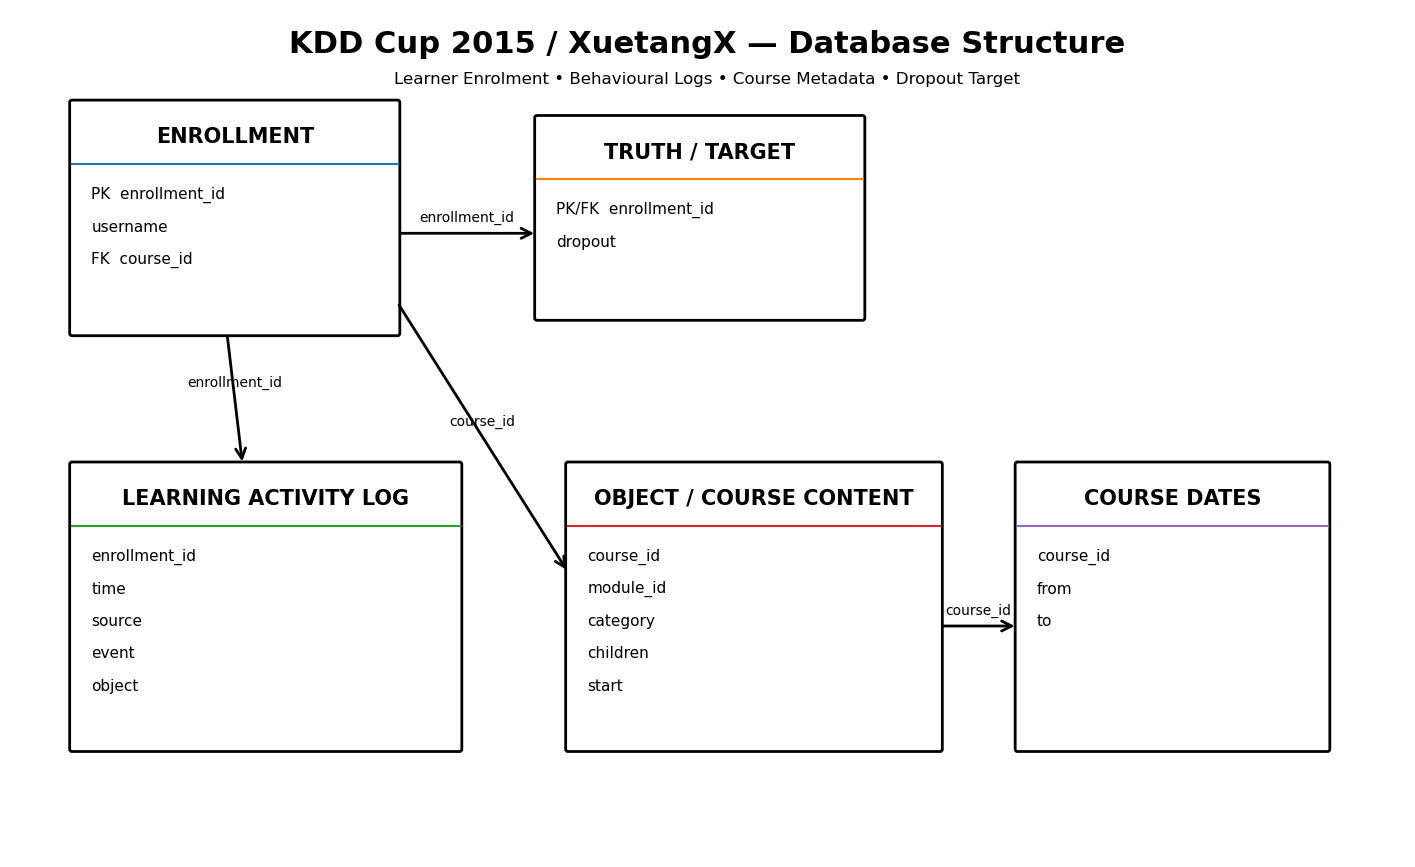

Saved to:
C:\Users\saura\KDDCup2015_research\results\KDDCup2015_database_structure.png


In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(18, 11))

ax.set_xlim(0, 18)
ax.set_ylim(0, 11)
ax.axis("off")

def draw_table(x, y, width, height, title, fields):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.03",
        linewidth=2,
        facecolor="white",
        edgecolor="black"
    )
    ax.add_patch(box)

    # Table title
    ax.text(
        x + width / 2,
        y + height - 0.45,
        title,
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold"
    )

    # Divider
    ax.plot(
        [x, x + width],
        [y + height - 0.8, y + height - 0.8],
        linewidth=1.5
    )

    # Fields
    start_y = y + height - 1.2

    for i, field in enumerate(fields):
        ax.text(
            x + 0.25,
            start_y - i * 0.42,
            field,
            ha="left",
            va="center",
            fontsize=11
        )


def arrow(x1, y1, x2, y2, label=None):
    arr = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="->",
        mutation_scale=18,
        linewidth=2
    )
    ax.add_patch(arr)

    if label:
        ax.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2 + 0.15,
            label,
            ha="center",
            fontsize=10
        )


# ---------------------------------------------------------
# TABLES
# ---------------------------------------------------------

# Enrollment
draw_table(
    0.8, 6.8, 4.2, 3.0,
    "ENROLLMENT",
    [
        "PK  enrollment_id",
        "username",
        "FK  course_id"
    ]
)

# Truth / Target
draw_table(
    6.8, 7.0, 4.2, 2.6,
    "TRUTH / TARGET",
    [
        "PK/FK  enrollment_id",
        "dropout"
    ]
)

# Log
draw_table(
    0.8, 1.4, 5.0, 3.7,
    "LEARNING ACTIVITY LOG",
    [
        "enrollment_id",
        "time",
        "source",
        "event",
        "object"
    ]
)

# Object
draw_table(
    7.2, 1.4, 4.8, 3.7,
    "OBJECT / COURSE CONTENT",
    [
        "course_id",
        "module_id",
        "category",
        "children",
        "start"
    ]
)

# Date
draw_table(
    13.0, 1.4, 4.0, 3.7,
    "COURSE DATES",
    [
        "course_id",
        "from",
        "to"
    ]
)


# ---------------------------------------------------------
# RELATIONSHIPS
# ---------------------------------------------------------

# Enrollment -> Truth
arrow(
    5.0, 8.1,
    6.8, 8.1,
    "enrollment_id"
)

# Enrollment -> Log
arrow(
    2.8, 6.8,
    3.0, 5.1,
    "enrollment_id"
)

# Enrollment -> Object
arrow(
    5.0, 7.2,
    7.2, 3.7,
    "course_id"
)

# Object -> Date
arrow(
    12.0, 3.0,
    13.0, 3.0,
    "course_id"
)


# ---------------------------------------------------------
# TITLE
# ---------------------------------------------------------

ax.text(
    9,
    10.55,
    "KDD Cup 2015 / XuetangX — Database Structure",
    ha="center",
    va="center",
    fontsize=22,
    fontweight="bold"
)

ax.text(
    9,
    10.1,
    "Learner Enrolment • Behavioural Logs • Course Metadata • Dropout Target",
    ha="center",
    va="center",
    fontsize=12
)


# ---------------------------------------------------------
# SAVE
# ---------------------------------------------------------

output_file = BASE / "results" / "KDDCup2015_database_structure.png"

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:")
print(output_file)

In [3]:
# Step 9: Inspect the training activity log

log_train_path = files["log_train"]

print("Log file:")
print(log_train_path)

print("\nReading first 10,000 rows...")

log_sample = pd.read_csv(
    log_train_path,
    nrows=10000
)

print("\nShape of sample:")
print(log_sample.shape)

print("\nColumns:")
print(log_sample.columns.tolist())

print("\nData types:")
print(log_sample.dtypes)

print("\nFirst 5 rows:")
display(log_sample.head())

Log file:
C:\Users\saura\KDDCup2015_research\data\raw\kddcup2015\train\log_train.csv

Reading first 10,000 rows...

Shape of sample:
(10000, 5)

Columns:
['enrollment_id', 'time', 'source', 'event', 'object']

Data types:
enrollment_id     int64
time             object
source           object
event            object
object           object
dtype: object

First 5 rows:


,enrollment_id,time,source,event,object
0,1,2014-06-14T09:38:29,server,navigate,Oj6eQgzrdqBMlaCtaq1IkY6zruSrb71b
1,1,2014-06-14T09:38:39,server,access,3T6XwoiMKgol57cm29Rjy8FXVFcIomxl
2,1,2014-06-14T09:38:39,server,access,qxvBNYTfiRkNcCvM0hcGwG6hvHdQwnd4
3,1,2014-06-14T09:38:48,server,access,2cmZrZW2h6Il91itO3e89FGcABLWhf3W
4,1,2014-06-14T09:41:49,browser,problem,RMtgC2bTAqEeftenUUyia504wsyzeZWf


In [4]:
print("=== ACTIVITY LOG SUMMARY ===")

print("\nNumber of rows inspected:", len(log_sample))

print("\nSOURCE DISTRIBUTION:")
print(log_sample["source"].value_counts())

print("\nEVENT DISTRIBUTION:")
print(log_sample["event"].value_counts())

print("\nUNIQUE ENROLLMENTS:")
print(log_sample["enrollment_id"].nunique())

print("\nTIME RANGE:")
print("First:", log_sample["time"].min())
print("Last: ", log_sample["time"].max())

print("\nUNIQUE OBJECTS:")
print(log_sample["object"].nunique())

=== ACTIVITY LOG SUMMARY ===

Number of rows inspected: 10000

SOURCE DISTRIBUTION:
source
server     5433
browser    4567
Name: count, dtype: int64

EVENT DISTRIBUTION:
event
access        3614
discussion    1778
page_close    1506
problem       1290
video         1011
navigate       786
wiki            15
Name: count, dtype: int64

UNIQUE ENROLLMENTS:
32

TIME RANGE:
First: 2014-06-09T00:40:16
Last:  2014-07-18T23:08:33

UNIQUE OBJECTS:
477


In [5]:
# ============================================================
# STEP 11 — FULL TRAINING LOG FEATURE EXTRACTION
# ============================================================

from collections import defaultdict

CHUNK_SIZE = 100_000

features = defaultdict(lambda: {
    "total_interactions": 0,
    "active_days": set(),
    "unique_objects": set(),

    "server_interactions": 0,
    "browser_interactions": 0,

    "access_events": 0,
    "navigate_events": 0,
    "problem_events": 0,
    "video_events": 0,
    "discussion_events": 0,
    "wiki_events": 0,
    "page_close_events": 0
})

chunk_number = 0

print("Starting full log processing...")
print("File size: approximately 589 MB")
print("Chunk size:", CHUNK_SIZE)
print()

for chunk in pd.read_csv(
    files["log_train"],
    chunksize=CHUNK_SIZE
):

    chunk_number += 1

    # Convert timestamp
    chunk["time"] = pd.to_datetime(
        chunk["time"],
        errors="coerce"
    )

    # Process each enrollment
    for enrollment_id, group in chunk.groupby("enrollment_id"):

        f = features[enrollment_id]

        # Total interactions
        f["total_interactions"] += len(group)

        # Active days
        f["active_days"].update(
            group["time"].dt.date.dropna()
        )

        # Unique learning objects
        f["unique_objects"].update(
            group["object"].dropna()
        )

        # Source
        f["server_interactions"] += (
            group["source"] == "server"
        ).sum()

        f["browser_interactions"] += (
            group["source"] == "browser"
        ).sum()

        # Event counts
        f["access_events"] += (
            group["event"] == "access"
        ).sum()

        f["navigate_events"] += (
            group["event"] == "navigate"
        ).sum()

        f["problem_events"] += (
            group["event"] == "problem"
        ).sum()

        f["video_events"] += (
            group["event"] == "video"
        ).sum()

        f["discussion_events"] += (
            group["event"] == "discussion"
        ).sum()

        f["wiki_events"] += (
            group["event"] == "wiki"
        ).sum()

        f["page_close_events"] += (
            group["event"] == "page_close"
        ).sum()

    # Progress
    if chunk_number % 10 == 0:
        print(
            f"Processed approximately "
            f"{chunk_number * CHUNK_SIZE:,} rows..."
        )

print()
print("============================================")
print("FULL LOG PROCESSING COMPLETED")
print("============================================")
print("Chunks processed:", chunk_number)
print("Enrolments with activity:", len(features))

Starting full log processing...
File size: approximately 589 MB
Chunk size: 100000

Processed approximately 1,000,000 rows...
Processed approximately 2,000,000 rows...
Processed approximately 3,000,000 rows...
Processed approximately 4,000,000 rows...
Processed approximately 5,000,000 rows...
Processed approximately 6,000,000 rows...
Processed approximately 7,000,000 rows...
Processed approximately 8,000,000 rows...

FULL LOG PROCESSING COMPLETED
Chunks processed: 82
Enrolments with activity: 120542


In [6]:
# ============================================================
# STEP 12 — CREATE BEHAVIOURAL FEATURE DATAFRAME
# ============================================================

feature_rows = []

for enrollment_id, f in features.items():

    feature_rows.append({
        "enrollment_id": enrollment_id,

        "total_interactions": f["total_interactions"],
        "active_days": len(f["active_days"]),
        "unique_objects": len(f["unique_objects"]),

        "server_interactions": f["server_interactions"],
        "browser_interactions": f["browser_interactions"],

        "access_events": f["access_events"],
        "navigate_events": f["navigate_events"],
        "problem_events": f["problem_events"],
        "video_events": f["video_events"],
        "discussion_events": f["discussion_events"],
        "wiki_events": f["wiki_events"],
        "page_close_events": f["page_close_events"]
    })

features_df = pd.DataFrame(feature_rows)

print("=== BEHAVIOURAL FEATURE DATASET ===")
print("Shape:", features_df.shape)

print("\nColumns:")
print(features_df.columns.tolist())

print("\nFirst 10 rows:")
display(features_df.head(10))

=== BEHAVIOURAL FEATURE DATASET ===
Shape: (120542, 13)

Columns:
['enrollment_id', 'total_interactions', 'active_days', 'unique_objects', 'server_interactions', 'browser_interactions', 'access_events', 'navigate_events', 'problem_events', 'video_events', 'discussion_events', 'wiki_events', 'page_close_events']

First 10 rows:


,enrollment_id,total_interactions,active_days,unique_objects,server_interactions,browser_interactions,access_events,navigate_events,problem_events,video_events,discussion_events,wiki_events,page_close_events
0,1,314,14,95,119,195,107,25,87,29,0,0,66
1,3,288,9,99,88,200,79,14,138,9,26,0,22
2,4,99,9,29,80,19,64,15,6,4,0,0,10
3,5,633,11,111,202,431,226,30,170,86,34,0,87
4,6,23,2,16,17,6,12,5,2,2,0,0,2
5,7,479,10,86,154,325,203,20,94,69,33,0,60
6,9,97,6,38,80,17,71,12,6,2,0,0,6
7,12,127,10,36,53,74,46,6,0,31,1,0,43
8,13,463,8,100,149,314,200,15,150,69,4,0,25
9,14,102,8,44,83,19,60,20,12,5,0,0,5


In [7]:
# ============================================================
# STEP 12B — FEATURE QUALITY CHECK
# ============================================================

print("=== FEATURE QUALITY CHECK ===")

print("\nShape:")
print(features_df.shape)

print("\nMissing values:")
print(features_df.isna().sum())

print("\nDuplicate enrollment IDs:")
print(features_df["enrollment_id"].duplicated().sum())

print("\nSummary statistics:")
display(features_df.describe())

=== FEATURE QUALITY CHECK ===

Shape:
(120542, 13)

Missing values:
enrollment_id           0
total_interactions      0
active_days             0
unique_objects          0
server_interactions     0
browser_interactions    0
access_events           0
navigate_events         0
problem_events          0
video_events            0
discussion_events       0
wiki_events             0
page_close_events       0
dtype: int64

Duplicate enrollment IDs:
0

Summary statistics:


,enrollment_id,total_interactions,active_days,unique_objects,server_interactions,browser_interactions,access_events,navigate_events,problem_events,video_events,discussion_events,wiki_events,page_close_events
count,120542.000000,120542.000000,120542.000000,120542.000000,120542.000000,120542.000000,120542.000000,120542.00000,120542.000000,120542.000000,120542.000000,120542.000000,120542.000000
mean,100364.330748,67.671658,2.668672,15.928025,35.567163,32.104495,25.818312,8.37309,10.462494,6.611455,5.386164,0.750834,10.269309
std,58003.738782,141.474642,3.113137,22.105776,77.562236,75.637151,54.419163,12.97447,34.407211,14.784320,37.976728,3.914958,20.848586
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50060.250000,5.000000,1.000000,4.000000,4.000000,0.000000,1.000000,2.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,100360.500000,17.000000,1.000000,8.000000,11.000000,5.000000,6.000000,4.00000,0.000000,1.000000,0.000000,0.000000,2.000000
75%,150658.500000,67.000000,3.000000,18.000000,36.000000,29.000000,26.000000,10.00000,6.000000,6.000000,2.000000,1.000000,10.000000
max,200905.000000,7697.000000,30.000000,316.000000,6678.000000,2311.000000,3659.000000,649.00000,1014.000000,536.000000,5321.000000,554.000000,521.000000


In [8]:
# ============================================================
# STEP 13 — MERGE BEHAVIOURAL FEATURES WITH DROPOUT LABEL
# ============================================================

print("=== TRUTH TRAIN ===")
print("Shape:", truth_train.shape)
print("Columns:", truth_train.columns.tolist())

print("\nFirst 5 rows:")
display(truth_train.head())

# Make sure enrollment_id is integer
truth_train["enrollment_id"] = truth_train["enrollment_id"].astype("int64")

# Make sure dropout is integer
truth_train["dropout"] = truth_train["dropout"].astype("int64")

# Merge
model_df = features_df.merge(
    truth_train[["enrollment_id", "dropout"]],
    on="enrollment_id",
    how="inner",
    validate="one_to_one"
)

print("\n============================================")
print("FINAL BEHAVIOURAL + LABEL DATASET")
print("============================================")

print("Shape:", model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

print("\nFirst 10 rows:")
display(model_df.head(10))

=== TRUTH TRAIN ===


NameError: name 'truth_train' is not defined

In [9]:
# ============================================================
# STEP 13A — RELOAD TRUTH TRAIN
# ============================================================

truth_train = pd.read_csv(
    files["truth_train"]
)

print("=== TRUTH TRAIN ===")
print("Shape:", truth_train.shape)
print("Columns:", truth_train.columns.tolist())

display(truth_train.head())

=== TRUTH TRAIN ===
Shape: (120541, 2)
Columns: ['1', '0']


,1,0
0,3,0
1,4,0
2,5,0
3,6,0
4,7,1


In [10]:
# Check the labels

print("Enrollment ID type:")
print(truth_train["enrollment_id"].dtype)

print("\nDropout type:")
print(truth_train["dropout"].dtype)

print("\nDropout distribution:")
print(truth_train["dropout"].value_counts())

print("\nMissing values:")
print(truth_train.isna().sum())

Enrollment ID type:


KeyError: 'enrollment_id'

In [11]:
# ============================================================
# STEP 13A — CORRECTLY LOAD TRUTH TRAIN
# ============================================================

truth_train = pd.read_csv(
    files["truth_train"],
    header=None,
    names=["enrollment_id", "dropout"]
)

print("=== TRUTH TRAIN ===")
print("Shape:", truth_train.shape)

print("\nColumns:")
print(truth_train.columns.tolist())

print("\nFirst 10 rows:")
display(truth_train.head(10))

print("\nData types:")
print(truth_train.dtypes)

=== TRUTH TRAIN ===
Shape: (120542, 2)

Columns:
['enrollment_id', 'dropout']

First 10 rows:


,enrollment_id,dropout
0,1,0
1,3,0
2,4,0
3,5,0
4,6,0
5,7,1
6,9,1
7,12,0
8,13,0
9,14,1



Data types:
enrollment_id    int64
dropout          int64
dtype: object


In [12]:
# ============================================================
# STEP 13B — MERGE BEHAVIOURAL FEATURES + DROPOUT LABEL
# ============================================================

# Ensure matching data types
features_df["enrollment_id"] = features_df["enrollment_id"].astype("int64")
truth_train["enrollment_id"] = truth_train["enrollment_id"].astype("int64")

# Merge
model_df = features_df.merge(
    truth_train,
    on="enrollment_id",
    how="inner",
    validate="one_to_one"
)

print("=== FINAL MODEL DATASET ===")
print("Shape:", model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

print("\nFirst 10 rows:")
display(model_df.head(10))

=== FINAL MODEL DATASET ===
Shape: (120542, 14)

Columns:
['enrollment_id', 'total_interactions', 'active_days', 'unique_objects', 'server_interactions', 'browser_interactions', 'access_events', 'navigate_events', 'problem_events', 'video_events', 'discussion_events', 'wiki_events', 'page_close_events', 'dropout']

First 10 rows:


,enrollment_id,total_interactions,active_days,unique_objects,server_interactions,browser_interactions,access_events,navigate_events,problem_events,video_events,discussion_events,wiki_events,page_close_events,dropout
0,1,314,14,95,119,195,107,25,87,29,0,0,66,0
1,3,288,9,99,88,200,79,14,138,9,26,0,22,0
2,4,99,9,29,80,19,64,15,6,4,0,0,10,0
3,5,633,11,111,202,431,226,30,170,86,34,0,87,0
4,6,23,2,16,17,6,12,5,2,2,0,0,2,0
5,7,479,10,86,154,325,203,20,94,69,33,0,60,1
6,9,97,6,38,80,17,71,12,6,2,0,0,6,1
7,12,127,10,36,53,74,46,6,0,31,1,0,43,0
8,13,463,8,100,149,314,200,15,150,69,4,0,25,0
9,14,102,8,44,83,19,60,20,12,5,0,0,5,1


In [13]:
# ============================================================
# STEP 13C — FINAL MODEL DATASET VALIDATION
# ============================================================

print("=== FINAL MODEL DATASET VALIDATION ===")

print("\nShape:")
print(model_df.shape)

print("\nMissing values:")
print(model_df.isna().sum().sum())

print("\nDuplicate enrollment IDs:")
print(model_df["enrollment_id"].duplicated().sum())

print("\nDropout distribution:")
print(model_df["dropout"].value_counts())

print("\nDropout percentage:")
print(
    (model_df["dropout"].value_counts(normalize=True) * 100)
    .round(2)
)

=== FINAL MODEL DATASET VALIDATION ===

Shape:
(120542, 14)

Missing values:
0

Duplicate enrollment IDs:
0

Dropout distribution:
dropout
1    95581
0    24961
Name: count, dtype: int64

Dropout percentage:
dropout
1    79.29
0    20.71
Name: proportion, dtype: float64


In [14]:
# ============================================================
# STEP 14 — SAVE BASELINE MODEL DATASET
# ============================================================

PROCESSED = BASE / "data" / "processed"

# Create processed directory if it doesn't exist
PROCESSED.mkdir(parents=True, exist_ok=True)

# Save dataset
baseline_path = PROCESSED / "KDDCup2015_baseline_features.csv"

model_df.to_csv(
    baseline_path,
    index=False
)

print("=== BASELINE DATASET SAVED ===")
print("Path:")
print(baseline_path)

print("\nShape:")
print(model_df.shape)

print("\nFile size:")
print(
    round(baseline_path.stat().st_size / (1024 * 1024), 2),
    "MB"
)

=== BASELINE DATASET SAVED ===
Path:
C:\Users\saura\KDDCup2015_research\data\processed\KDDCup2015_baseline_features.csv

Shape:
(120542, 14)

File size:
4.3 MB


In [15]:
# ============================================================
# STEP 15 — VERIFY SAVED BASELINE DATASET
# ============================================================

check_df = pd.read_csv(baseline_path)

print("=== SAVED DATASET VERIFICATION ===")

print("\nShape:")
print(check_df.shape)

print("\nColumns:")
print(check_df.columns.tolist())

print("\nMissing values:")
print(check_df.isna().sum().sum())

print("\nDuplicate enrollment IDs:")
print(check_df["enrollment_id"].duplicated().sum())

print("\nDropout distribution:")
print(check_df["dropout"].value_counts())

print("\nFirst 5 rows:")
display(check_df.head())

=== SAVED DATASET VERIFICATION ===

Shape:
(120542, 14)

Columns:
['enrollment_id', 'total_interactions', 'active_days', 'unique_objects', 'server_interactions', 'browser_interactions', 'access_events', 'navigate_events', 'problem_events', 'video_events', 'discussion_events', 'wiki_events', 'page_close_events', 'dropout']

Missing values:
0

Duplicate enrollment IDs:
0

Dropout distribution:
dropout
1    95581
0    24961
Name: count, dtype: int64

First 5 rows:


,enrollment_id,total_interactions,active_days,unique_objects,server_interactions,browser_interactions,access_events,navigate_events,problem_events,video_events,discussion_events,wiki_events,page_close_events,dropout
0,1,314,14,95,119,195,107,25,87,29,0,0,66,0
1,3,288,9,99,88,200,79,14,138,9,26,0,22,0
2,4,99,9,29,80,19,64,15,6,4,0,0,10,0
3,5,633,11,111,202,431,226,30,170,86,34,0,87,0
4,6,23,2,16,17,6,12,5,2,2,0,0,2,0


In [16]:
# ============================================================
# STEP 15 — VERIFY SAVED BASELINE DATASET
# ============================================================

check_df = pd.read_csv(baseline_path)

print("=== SAVED DATASET VERIFICATION ===")

print("\nShape:")
print(check_df.shape)

print("\nColumns:")
print(check_df.columns.tolist())

print("\nMissing values:")
print(check_df.isna().sum().sum())

print("\nDuplicate enrollment IDs:")
print(check_df["enrollment_id"].duplicated().sum())

print("\nDropout distribution:")
print(check_df["dropout"].value_counts())

print("\nFirst 5 rows:")
display(check_df.head())

=== SAVED DATASET VERIFICATION ===

Shape:
(120542, 14)

Columns:
['enrollment_id', 'total_interactions', 'active_days', 'unique_objects', 'server_interactions', 'browser_interactions', 'access_events', 'navigate_events', 'problem_events', 'video_events', 'discussion_events', 'wiki_events', 'page_close_events', 'dropout']

Missing values:
0

Duplicate enrollment IDs:
0

Dropout distribution:
dropout
1    95581
0    24961
Name: count, dtype: int64

First 5 rows:


,enrollment_id,total_interactions,active_days,unique_objects,server_interactions,browser_interactions,access_events,navigate_events,problem_events,video_events,discussion_events,wiki_events,page_close_events,dropout
0,1,314,14,95,119,195,107,25,87,29,0,0,66,0
1,3,288,9,99,88,200,79,14,138,9,26,0,22,0
2,4,99,9,29,80,19,64,15,6,4,0,0,10,0
3,5,633,11,111,202,431,226,30,170,86,34,0,87,0
4,6,23,2,16,17,6,12,5,2,2,0,0,2,0


In [17]:
# ============================================================
# STEP 16 — INSPECT COURSE DATES
# ============================================================

print("=== COURSE DATE DATA ===")

print("Shape:", date_df.shape)

print("\nColumns:")
print(date_df.columns.tolist())

print("\nData types:")
print(date_df.dtypes)

print("\nFirst 10 rows:")
display(date_df.head(10))

print("\nMissing values:")
print(date_df.isna().sum())

=== COURSE DATE DATA ===


NameError: name 'date_df' is not defined

In [18]:
from pathlib import Path
import pandas as pd

BASE = Path(r"C:\Users\saura\KDDCup2015_research")
RAW = BASE / "data" / "raw" / "kddcup2015"

date_path = RAW / "date.csv"

date_df = pd.read_csv(date_path)

print("=== COURSE DATE DATA ===")
print("Shape:", date_df.shape)
print("Columns:", date_df.columns.tolist())
print("\nData types:")
print(date_df.dtypes)

print("\nFirst 10 rows:")
display(date_df.head(10))

print("\nMissing values:")
print(date_df.isna().sum())

=== COURSE DATE DATA ===
Shape: (39, 3)
Columns: ['course_id', 'from', 'to']

Data types:
course_id    object
from         object
to           object
dtype: object

First 10 rows:


,course_id,from,to
0,bWdj2GDclj5ofokWjzoa5jAwMkxCykd6,2014-05-26,2014-06-24
1,RXDvfPUBYFlVdlueBFbLW0mhhAyGEqpt,2014-05-25,2014-06-23
2,fbPkOYLVPtPgIt0MxizjfFJov3JbHyAi,2014-01-17,2014-02-15
3,A3fsA9Zfv1X2fVEQhTw51lKENdNrEqT3,2014-05-28,2014-06-26
4,5X6FeZozNMgE2VRi3MJYjkkFK8SETtu2,2014-06-09,2014-07-08
5,5Gyp41oLVo7Gg7vF4vpmggWP5MU70QO6,2013-12-11,2014-01-09
6,SpATywNh6bZuzm8s1ceuBUnMUAeoAHHw,2014-05-26,2014-06-24
7,3VkHkmOtom3jM2wCu94xgzzu1d6Dn7or,2013-11-01,2013-11-30
8,G8EPVSXsOYB5YQWZGiz1aVq5Pgr2GrQu,2014-05-25,2014-06-23
9,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,2014-06-19,2014-07-18



Missing values:
course_id    0
from         0
to           0
dtype: int64


In [19]:
# ============================================================
# STEP 16B — CONVERT COURSE DATES TO DATETIME
# ============================================================

date_df["from"] = pd.to_datetime(date_df["from"])
date_df["to"] = pd.to_datetime(date_df["to"])

print("=== CONVERTED COURSE DATES ===")

print("\nData types:")
print(date_df.dtypes)

print("\nFirst 10 courses:")
display(date_df.head(10))

print("\nCourse duration:")
date_df["course_duration_days"] = (
    date_df["to"] - date_df["from"]
).dt.days

display(
    date_df[
        ["course_id", "from", "to", "course_duration_days"]
    ].head(10)
)

=== CONVERTED COURSE DATES ===

Data types:
course_id            object
from         datetime64[ns]
to           datetime64[ns]
dtype: object

First 10 courses:


,course_id,from,to
0,bWdj2GDclj5ofokWjzoa5jAwMkxCykd6,2014-05-26,2014-06-24
1,RXDvfPUBYFlVdlueBFbLW0mhhAyGEqpt,2014-05-25,2014-06-23
2,fbPkOYLVPtPgIt0MxizjfFJov3JbHyAi,2014-01-17,2014-02-15
3,A3fsA9Zfv1X2fVEQhTw51lKENdNrEqT3,2014-05-28,2014-06-26
4,5X6FeZozNMgE2VRi3MJYjkkFK8SETtu2,2014-06-09,2014-07-08
5,5Gyp41oLVo7Gg7vF4vpmggWP5MU70QO6,2013-12-11,2014-01-09
6,SpATywNh6bZuzm8s1ceuBUnMUAeoAHHw,2014-05-26,2014-06-24
7,3VkHkmOtom3jM2wCu94xgzzu1d6Dn7or,2013-11-01,2013-11-30
8,G8EPVSXsOYB5YQWZGiz1aVq5Pgr2GrQu,2014-05-25,2014-06-23
9,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,2014-06-19,2014-07-18



Course duration:


,course_id,from,to,course_duration_days
0,bWdj2GDclj5ofokWjzoa5jAwMkxCykd6,2014-05-26,2014-06-24,29
1,RXDvfPUBYFlVdlueBFbLW0mhhAyGEqpt,2014-05-25,2014-06-23,29
2,fbPkOYLVPtPgIt0MxizjfFJov3JbHyAi,2014-01-17,2014-02-15,29
3,A3fsA9Zfv1X2fVEQhTw51lKENdNrEqT3,2014-05-28,2014-06-26,29
4,5X6FeZozNMgE2VRi3MJYjkkFK8SETtu2,2014-06-09,2014-07-08,29
5,5Gyp41oLVo7Gg7vF4vpmggWP5MU70QO6,2013-12-11,2014-01-09,29
6,SpATywNh6bZuzm8s1ceuBUnMUAeoAHHw,2014-05-26,2014-06-24,29
7,3VkHkmOtom3jM2wCu94xgzzu1d6Dn7or,2013-11-01,2013-11-30,29
8,G8EPVSXsOYB5YQWZGiz1aVq5Pgr2GrQu,2014-05-25,2014-06-23,29
9,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,2014-06-19,2014-07-18,29


In [20]:
# ============================================================
# STEP 17 — CONNECT ENROLMENTS TO COURSE DATES
# ============================================================

enrollment_train = pd.read_csv(
    RAW / "train" / "enrollment_train.csv"
)

print("=== ENROLLMENT TRAIN ===")
print("Shape:", enrollment_train.shape)
print("Columns:", enrollment_train.columns.tolist())

# Merge course dates
enrollment_with_dates = enrollment_train.merge(
    date_df[
        ["course_id", "from", "to", "course_duration_days"]
    ],
    on="course_id",
    how="left",
    validate="many_to_one"
)

print("\n=== ENROLLMENT + COURSE DATES ===")
print("Shape:", enrollment_with_dates.shape)

print("\nMissing course dates:")
print(
    enrollment_with_dates[
        ["from", "to"]
    ].isna().sum()
)

print("\nFirst 5 rows:")
display(enrollment_with_dates.head())

=== ENROLLMENT TRAIN ===
Shape: (120542, 3)
Columns: ['enrollment_id', 'username', 'course_id']

=== ENROLLMENT + COURSE DATES ===
Shape: (120542, 6)

Missing course dates:
from    0
to      0
dtype: int64

First 5 rows:


,enrollment_id,username,course_id,from,to,course_duration_days
0,1,9Uee7oEuuMmgPx2IzPfFkWgkHZyPbWr0,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,2014-06-12,2014-07-11,29
1,3,1qXC7Fjbwp66GPQc6pHLfEuO8WKozxG4,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,2014-06-19,2014-07-18,29
2,4,FIHlppZyoq8muPbdVxS44gfvceX9zvU7,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,2014-06-12,2014-07-11,29
3,5,p1Mp7WkVfzUijX0peVQKSHbgd5pXyl4c,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,2014-06-19,2014-07-18,29
4,6,dpK33RH9yepUAnyoywRwBt1AJzxGlaja,AXUJZGmZ0xaYSWazu8RQ1G5c76ECT1Kd,2014-06-04,2014-07-03,29


In [21]:
# ============================================================
# STEP 18 — CHECK ACTIVITY DATA
# ============================================================

print("=== CHECKING ACTIVITY DATA ===")

print("Available variables:")
print([
    name for name in [
        "log_train",
        "log_df",
        "activity_df",
        "features_df",
        "model_df"
    ]
    if name in globals()
])

=== CHECKING ACTIVITY DATA ===
Available variables:
['features_df', 'model_df']


In [22]:
# ============================================================
# STEP 18A — EARLY-STAGE FEATURE EXTRACTION
# ============================================================

from pathlib import Path
import pandas as pd

BASE = Path(r"C:\Users\saura\KDDCup2015_research")
RAW = BASE / "data" / "raw" / "kddcup2015"

LOG_PATH = RAW / "train" / "log_train.csv"
ENROLLMENT_PATH = RAW / "train" / "enrollment_train.csv"
DATE_PATH = RAW / "date.csv"

print("Checking files...")

print("Log:", LOG_PATH.exists())
print("Enrollment:", ENROLLMENT_PATH.exists())
print("Date:", DATE_PATH.exists())

print("\nLog size:")
print(round(LOG_PATH.stat().st_size / (1024 * 1024), 2), "MB")

Checking files...
Log: True
Enrollment: True
Date: True

Log size:
589.63 MB


In [23]:
# ============================================================
# STEP 18B — PREPARE ENROLMENT COURSE TIMELINE
# ============================================================

enrollment_train = pd.read_csv(ENROLLMENT_PATH)

date_df = pd.read_csv(DATE_PATH)

date_df["from"] = pd.to_datetime(date_df["from"])
date_df["to"] = pd.to_datetime(date_df["to"])

enrollment_dates = enrollment_train.merge(
    date_df[["course_id", "from", "to"]],
    on="course_id",
    how="left",
    validate="many_to_one"
)

print("=== ENROLMENT COURSE TIMELINE ===")

print("Shape:", enrollment_dates.shape)

print("\nMissing course dates:")
print(enrollment_dates[["from", "to"]].isna().sum())

display(enrollment_dates.head())

=== ENROLMENT COURSE TIMELINE ===
Shape: (120542, 5)

Missing course dates:
from    0
to      0
dtype: int64


,enrollment_id,username,course_id,from,to
0,1,9Uee7oEuuMmgPx2IzPfFkWgkHZyPbWr0,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,2014-06-12,2014-07-11
1,3,1qXC7Fjbwp66GPQc6pHLfEuO8WKozxG4,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,2014-06-19,2014-07-18
2,4,FIHlppZyoq8muPbdVxS44gfvceX9zvU7,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,2014-06-12,2014-07-11
3,5,p1Mp7WkVfzUijX0peVQKSHbgd5pXyl4c,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,2014-06-19,2014-07-18
4,6,dpK33RH9yepUAnyoywRwBt1AJzxGlaja,AXUJZGmZ0xaYSWazu8RQ1G5c76ECT1Kd,2014-06-04,2014-07-03


In [24]:
# ============================================================
# STEP 18C — EXTRACT EARLY-STAGE BEHAVIOURAL FEATURES
# ============================================================

import pandas as pd
from collections import defaultdict

print("=== EARLY-STAGE LOG PROCESSING ===")
print("Processing log_train.csv in chunks...")
print("Windows: 7, 14 and 21 days")
print("Please wait — this may take some time.")

# ------------------------------------------------------------
# Create lookup: enrollment_id -> course start date
# ------------------------------------------------------------

course_start = enrollment_dates.set_index(
    "enrollment_id"
)["from"]

# ------------------------------------------------------------
# Feature containers
# ------------------------------------------------------------

windows = [7, 14, 21]

feature_store = {
    window: defaultdict(lambda: {
        "total_interactions": 0,
        "active_days": set(),
        "unique_objects": set(),
        "access_events": 0,
        "navigate_events": 0,
        "problem_events": 0,
        "video_events": 0,
        "discussion_events": 0,
        "wiki_events": 0,
        "page_close_events": 0
    })
    for window in windows
}

# ------------------------------------------------------------
# Process log in chunks
# ------------------------------------------------------------

chunk_size = 100000
chunks_processed = 0
rows_processed = 0

for chunk in pd.read_csv(
    LOG_PATH,
    chunksize=chunk_size
):

    chunks_processed += 1
    rows_processed += len(chunk)

    # Convert timestamps
    chunk["time"] = pd.to_datetime(
        chunk["time"],
        errors="coerce"
    )

    # Remove invalid timestamps
    chunk = chunk.dropna(subset=["time"])

    # Match course start date
    chunk["course_start"] = chunk[
        "enrollment_id"
    ].map(course_start)

    # Remove unmatched enrolments
    chunk = chunk.dropna(
        subset=["course_start"]
    )

    # Calculate days since course start
    chunk["days_since_start"] = (
        chunk["time"].dt.normalize()
        - chunk["course_start"].dt.normalize()
    ).dt.days

    # --------------------------------------------------------
    # Process each early window
    # --------------------------------------------------------

    for window in windows:

        early = chunk[
            (chunk["days_since_start"] >= 0)
            &
            (chunk["days_since_start"] < window)
        ]

        if early.empty:
            continue

        # Group by enrolment
        for enrollment_id, group in early.groupby(
            "enrollment_id"
        ):

            stats = feature_store[window][enrollment_id]

            stats["total_interactions"] += len(group)

            stats["active_days"].update(
                group["time"].dt.date.unique()
            )

            stats["unique_objects"].update(
                group["object"].dropna().unique()
            )

            stats["access_events"] += (
                group["event"] == "access"
            ).sum()

            stats["navigate_events"] += (
                group["event"] == "navigate"
            ).sum()

            stats["problem_events"] += (
                group["event"] == "problem"
            ).sum()

            stats["video_events"] += (
                group["event"] == "video"
            ).sum()

            stats["discussion_events"] += (
                group["event"] == "discussion"
            ).sum()

            stats["wiki_events"] += (
                group["event"] == "wiki"
            ).sum()

            stats["page_close_events"] += (
                group["event"] == "page_close"
            ).sum()

    # Progress message
    if chunks_processed % 10 == 0:
        print(
            f"Processed approximately "
            f"{rows_processed:,} rows..."
        )

print("\n============================================")
print("EARLY-STAGE PROCESSING COMPLETED")
print("============================================")
print("Chunks processed:", chunks_processed)
print("Rows processed:", f"{rows_processed:,}")

=== EARLY-STAGE LOG PROCESSING ===
Processing log_train.csv in chunks...
Windows: 7, 14 and 21 days
Please wait — this may take some time.
Processed approximately 1,000,000 rows...
Processed approximately 2,000,000 rows...
Processed approximately 3,000,000 rows...
Processed approximately 4,000,000 rows...
Processed approximately 5,000,000 rows...
Processed approximately 6,000,000 rows...
Processed approximately 7,000,000 rows...
Processed approximately 8,000,000 rows...

EARLY-STAGE PROCESSING COMPLETED
Chunks processed: 82
Rows processed: 8,157,277


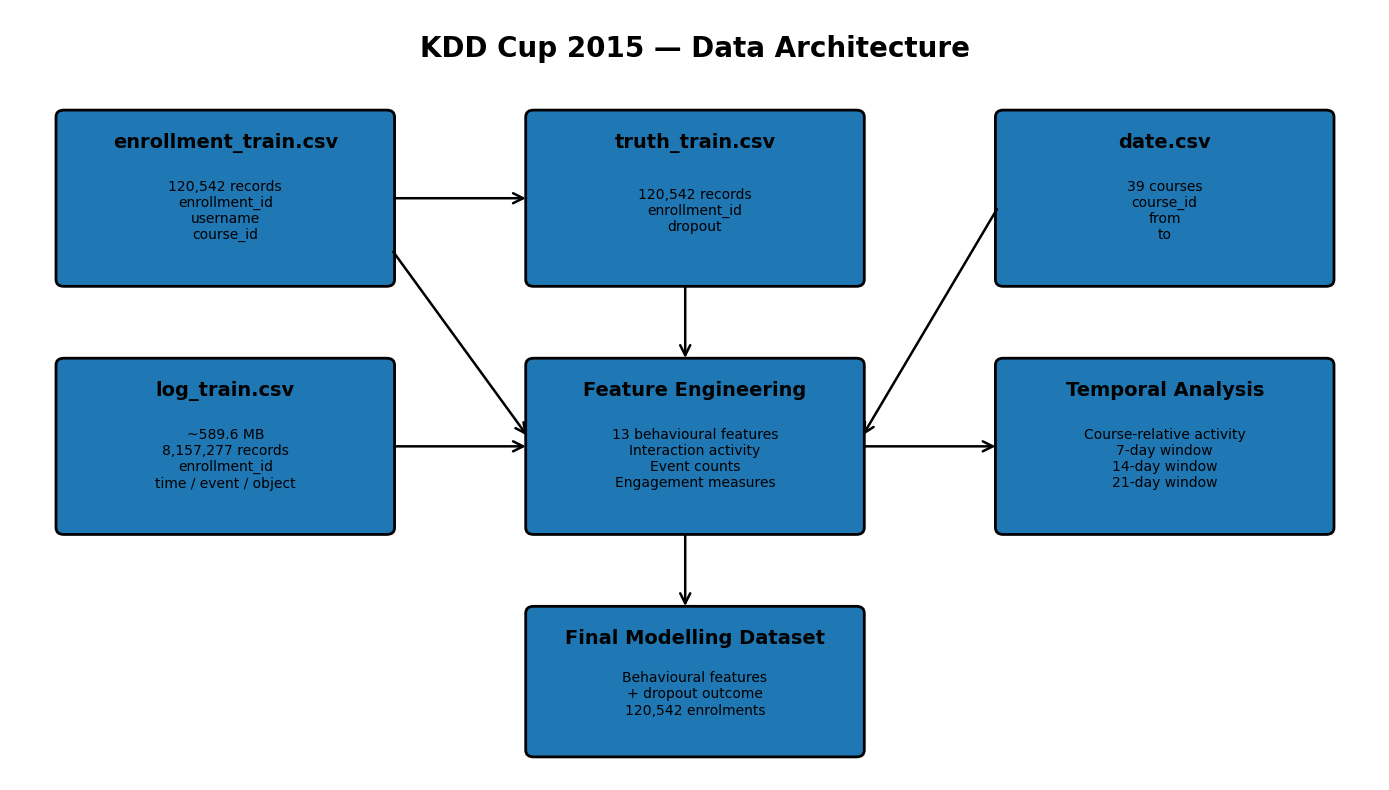

Saved: C:\Users\saura\KDDCup2015_research\results\KDDCup2015_database_structure.png


In [25]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 8))

ax.set_xlim(0, 14)
ax.set_ylim(0, 9)
ax.axis("off")

def box(x, y, w, h, title, lines):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=2
    )
    ax.add_patch(patch)

    ax.text(
        x + w/2, y + h - 0.35,
        title,
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold"
    )

    ax.text(
        x + w/2, y + h/2 - 0.15,
        "\n".join(lines),
        ha="center",
        va="center",
        fontsize=10
    )

def arrow(x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="->",
            mutation_scale=18,
            linewidth=1.8
        )
    )

# Main tables
box(0.5, 5.8, 3.4, 2.0,
    "enrollment_train.csv",
    ["120,542 records",
     "enrollment_id",
     "username",
     "course_id"])

box(5.3, 5.8, 3.4, 2.0,
    "truth_train.csv",
    ["120,542 records",
     "enrollment_id",
     "dropout"])

box(10.1, 5.8, 3.4, 2.0,
    "date.csv",
    ["39 courses",
     "course_id",
     "from",
     "to"])

box(0.5, 2.9, 3.4, 2.0,
    "log_train.csv",
    ["~589.6 MB",
     "8,157,277 records",
     "enrollment_id",
     "time / event / object"])

box(5.3, 2.9, 3.4, 2.0,
    "Feature Engineering",
    ["13 behavioural features",
     "Interaction activity",
     "Event counts",
     "Engagement measures"])

box(10.1, 2.9, 3.4, 2.0,
    "Temporal Analysis",
    ["Course-relative activity",
     "7-day window",
     "14-day window",
     "21-day window"])

box(5.3, 0.3, 3.4, 1.7,
    "Final Modelling Dataset",
    ["Behavioural features",
     "+ dropout outcome",
     "120,542 enrolments"])

# Connections
arrow(3.9, 6.8, 5.3, 6.8)
arrow(3.9, 6.2, 5.3, 4.0)
arrow(6.9, 5.8, 6.9, 4.9)
arrow(10.1, 6.7, 8.7, 4.0)
arrow(3.9, 3.9, 5.3, 3.9)
arrow(8.7, 3.9, 10.1, 3.9)
arrow(6.9, 2.9, 6.9, 2.0)

ax.text(
    7, 8.45,
    "KDD Cup 2015 — Data Architecture",
    ha="center",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

output = r"C:\Users\saura\KDDCup2015_research\results\KDDCup2015_database_structure.png"

plt.savefig(output, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", output)

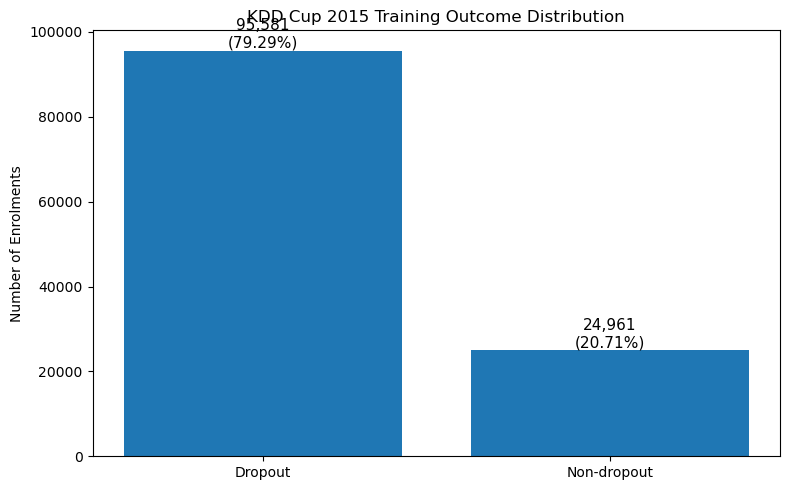

Saved: C:\Users\saura\KDDCup2015_research\results\dropout_distribution.png


In [26]:
import matplotlib.pyplot as plt

labels = ["Dropout", "Non-dropout"]
values = [95581, 24961]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.title("KDD Cup 2015 Training Outcome Distribution")
plt.ylabel("Number of Enrolments")

for bar, value in zip(bars, values):
    percentage = value / sum(values) * 100
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

output = r"C:\Users\saura\KDDCup2015_research\results\dropout_distribution.png"

plt.savefig(output, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", output)

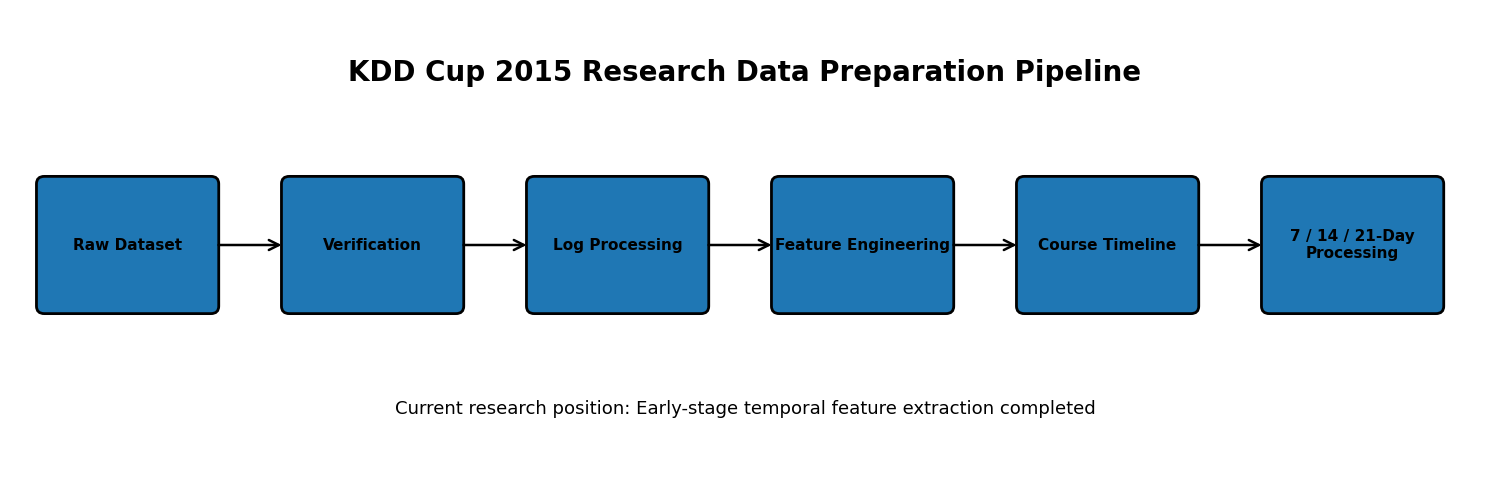

Saved: C:\Users\saura\KDDCup2015_research\results\KDDCup2015_research_pipeline.png


In [27]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(15, 5))

ax.set_xlim(0, 15)
ax.set_ylim(0, 5)
ax.axis("off")

steps = [
    "Raw Dataset",
    "Verification",
    "Log Processing",
    "Feature Engineering",
    "Course Timeline",
    "7 / 14 / 21-Day\nProcessing"
]

x_positions = [0.3, 2.8, 5.3, 7.8, 10.3, 12.8]

for x, step in zip(x_positions, steps):

    box = FancyBboxPatch(
        (x, 1.8),
        1.8,
        1.4,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=2
    )

    ax.add_patch(box)

    ax.text(
        x + 0.9,
        2.5,
        step,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

for i in range(len(x_positions) - 1):

    ax.add_patch(
        FancyArrowPatch(
            (x_positions[i] + 1.8, 2.5),
            (x_positions[i+1], 2.5),
            arrowstyle="->",
            mutation_scale=18,
            linewidth=1.8
        )
    )

ax.text(
    7.5,
    4.25,
    "KDD Cup 2015 Research Data Preparation Pipeline",
    ha="center",
    fontsize=20,
    fontweight="bold"
)

ax.text(
    7.5,
    0.7,
    "Current research position: Early-stage temporal feature extraction completed",
    ha="center",
    fontsize=13
)

plt.tight_layout()

output = r"C:\Users\saura\KDDCup2015_research\results\KDDCup2015_research_pipeline.png"

plt.savefig(output, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", output)

In [1]:
print("=== CURRENT VARIABLES ===")
print([x for x in globals().keys() if not x.startswith("_")])

=== CURRENT VARIABLES ===
['In', 'Out', 'get_ipython', 'exit', 'quit', 'open']


In [2]:
# ============================================================
# STEP 18D — RELOAD DATA REQUIRED FOR EARLY-STAGE PROCESSING
# ============================================================

from pathlib import Path
import pandas as pd

BASE = Path(r"C:\Users\saura\KDDCup2015_research")
RAW = BASE / "data" / "raw" / "kddcup2015"
PROCESSED = BASE / "data" / "processed"

# File paths
ENROLLMENT_TRAIN_PATH = RAW / "train" / "enrollment_train.csv"
DATE_PATH = RAW / "date.csv"
LOG_PATH = RAW / "train" / "log_train.csv"

# ------------------------------------------------------------
# Load enrollment data
# ------------------------------------------------------------

enrollment_train = pd.read_csv(
    ENROLLMENT_TRAIN_PATH
)

print("Enrollment train:", enrollment_train.shape)

# ------------------------------------------------------------
# Load course dates
# ------------------------------------------------------------

date_df = pd.read_csv(
    DATE_PATH
)

print("Course dates:", date_df.shape)

# ------------------------------------------------------------
# Prepare dates
# ------------------------------------------------------------

date_df["from"] = pd.to_datetime(
    date_df["from"],
    errors="coerce"
)

date_df["to"] = pd.to_datetime(
    date_df["to"],
    errors="coerce"
)

# ------------------------------------------------------------
# Merge enrollment with course dates
# ------------------------------------------------------------

enrollment_dates = enrollment_train.merge(
    date_df,
    on="course_id",
    how="left"
)

print("\n=== ENROLLMENT DATES ===")
print("Shape:", enrollment_dates.shape)

print("\nMissing course start dates:")
print(enrollment_dates["from"].isna().sum())

print("\nMissing course end dates:")
print(enrollment_dates["to"].isna().sum())

print("\nFirst 5 rows:")
display(enrollment_dates.head())

Enrollment train: (120542, 3)
Course dates: (39, 3)

=== ENROLLMENT DATES ===
Shape: (120542, 5)

Missing course start dates:
0

Missing course end dates:
0

First 5 rows:


,enrollment_id,username,course_id,from,to
0,1,9Uee7oEuuMmgPx2IzPfFkWgkHZyPbWr0,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,2014-06-12,2014-07-11
1,3,1qXC7Fjbwp66GPQc6pHLfEuO8WKozxG4,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,2014-06-19,2014-07-18
2,4,FIHlppZyoq8muPbdVxS44gfvceX9zvU7,DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila,2014-06-12,2014-07-11
3,5,p1Mp7WkVfzUijX0peVQKSHbgd5pXyl4c,7GRhBDsirIGkRZBtSMEzNTyDr2JQm4xx,2014-06-19,2014-07-18
4,6,dpK33RH9yepUAnyoywRwBt1AJzxGlaja,AXUJZGmZ0xaYSWazu8RQ1G5c76ECT1Kd,2014-06-04,2014-07-03


In [3]:
# ============================================================
# STEP 18C — EXTRACT EARLY-STAGE BEHAVIOURAL FEATURES
# ============================================================

import pandas as pd
from collections import defaultdict

print("=== EARLY-STAGE LOG PROCESSING ===")
print("Processing log_train.csv in chunks...")
print("Windows: 7, 14 and 21 days")
print("Please wait — this may take some time.")

# ------------------------------------------------------------
# Create lookup: enrollment_id -> course start date
# ------------------------------------------------------------

course_start = enrollment_dates.set_index(
    "enrollment_id"
)["from"]

# ------------------------------------------------------------
# Feature containers
# ------------------------------------------------------------

windows = [7, 14, 21]

feature_store = {
    window: defaultdict(lambda: {
        "total_interactions": 0,
        "active_days": set(),
        "unique_objects": set(),
        "access_events": 0,
        "navigate_events": 0,
        "problem_events": 0,
        "video_events": 0,
        "discussion_events": 0,
        "wiki_events": 0,
        "page_close_events": 0
    })
    for window in windows
}

# ------------------------------------------------------------
# Process log in chunks
# ------------------------------------------------------------

chunk_size = 100000
chunks_processed = 0
rows_processed = 0

for chunk in pd.read_csv(
    LOG_PATH,
    chunksize=chunk_size
):

    chunks_processed += 1
    rows_processed += len(chunk)

    # Convert timestamps
    chunk["time"] = pd.to_datetime(
        chunk["time"],
        errors="coerce"
    )

    # Remove invalid timestamps
    chunk = chunk.dropna(
        subset=["time"]
    )

    # Match course start date
    chunk["course_start"] = chunk[
        "enrollment_id"
    ].map(course_start)

    # Remove unmatched enrolments
    chunk = chunk.dropna(
        subset=["course_start"]
    )

    # Calculate days since course start
    chunk["days_since_start"] = (
        chunk["time"].dt.normalize()
        - chunk["course_start"].dt.normalize()
    ).dt.days

    # --------------------------------------------------------
    # Process each early window
    # --------------------------------------------------------

    for window in windows:

        early = chunk[
            (chunk["days_since_start"] >= 0)
            &
            (chunk["days_since_start"] < window)
        ]

        if early.empty:
            continue

        # Group by enrolment
        for enrollment_id, group in early.groupby(
            "enrollment_id"
        ):

            stats = feature_store[
                window
            ][enrollment_id]

            stats["total_interactions"] += len(group)

            stats["active_days"].update(
                group["time"].dt.date.unique()
            )

            stats["unique_objects"].update(
                group["object"].dropna().unique()
            )

            stats["access_events"] += (
                group["event"] == "access"
            ).sum()

            stats["navigate_events"] += (
                group["event"] == "navigate"
            ).sum()

            stats["problem_events"] += (
                group["event"] == "problem"
            ).sum()

            stats["video_events"] += (
                group["event"] == "video"
            ).sum()

            stats["discussion_events"] += (
                group["event"] == "discussion"
            ).sum()

            stats["wiki_events"] += (
                group["event"] == "wiki"
            ).sum()

            stats["page_close_events"] += (
                group["event"] == "page_close"
            ).sum()

    # --------------------------------------------------------
    # Progress message
    # --------------------------------------------------------

    if chunks_processed % 10 == 0:
        print(
            f"Processed approximately "
            f"{rows_processed:,} rows..."
        )

# ------------------------------------------------------------
# Completion
# ------------------------------------------------------------

print("\n============================================")
print("EARLY-STAGE PROCESSING COMPLETED")
print("============================================")
print("Chunks processed:", chunks_processed)
print("Rows processed:", f"{rows_processed:,}")

# ------------------------------------------------------------
# Check feature store
# ------------------------------------------------------------

print("\n=== FEATURE STORE CHECK ===")

for window in windows:
    print(
        f"{window}-day window: "
        f"{len(feature_store[window]):,} enrolments"
    )

=== EARLY-STAGE LOG PROCESSING ===
Processing log_train.csv in chunks...
Windows: 7, 14 and 21 days
Please wait — this may take some time.
Processed approximately 1,000,000 rows...
Processed approximately 2,000,000 rows...
Processed approximately 3,000,000 rows...
Processed approximately 4,000,000 rows...
Processed approximately 5,000,000 rows...
Processed approximately 6,000,000 rows...
Processed approximately 7,000,000 rows...
Processed approximately 8,000,000 rows...

EARLY-STAGE PROCESSING COMPLETED
Chunks processed: 82
Rows processed: 8,157,277

=== FEATURE STORE CHECK ===
7-day window: 59,195 enrolments
14-day window: 83,798 enrolments
21-day window: 101,861 enrolments


In [4]:
# ============================================================
# STEP 19 — CREATE 7, 14 AND 21-DAY FEATURE DATASETS
# ============================================================

import pandas as pd

print("=== CREATING EARLY-STAGE FEATURE DATASETS ===")

def create_feature_dataframe(window):
    
    records = []

    for enrollment_id, stats in feature_store[window].items():
        
        records.append({
            "enrollment_id": enrollment_id,
            "total_interactions": stats["total_interactions"],
            "active_days": len(stats["active_days"]),
            "unique_objects": len(stats["unique_objects"]),
            "access_events": stats["access_events"],
            "navigate_events": stats["navigate_events"],
            "problem_events": stats["problem_events"],
            "video_events": stats["video_events"],
            "discussion_events": stats["discussion_events"],
            "wiki_events": stats["wiki_events"],
            "page_close_events": stats["page_close_events"]
        })

    df = pd.DataFrame(records)

    return df


# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------

features_7d = create_feature_dataframe(7)
features_14d = create_feature_dataframe(14)
features_21d = create_feature_dataframe(21)


# ------------------------------------------------------------
# Display shapes
# ------------------------------------------------------------

print("\n=== DATASET SHAPES ===")

print("7-day :", features_7d.shape)
print("14-day:", features_14d.shape)
print("21-day:", features_21d.shape)


# ------------------------------------------------------------
# Display columns
# ------------------------------------------------------------

print("\n=== COLUMNS ===")

print("7-day:")
print(features_7d.columns.tolist())

print("\n14-day:")
print(features_14d.columns.tolist())

print("\n21-day:")
print(features_21d.columns.tolist())


# ------------------------------------------------------------
# First 5 rows
# ------------------------------------------------------------

print("\n=== 7-DAY FEATURES ===")
display(features_7d.head())

print("\n=== 14-DAY FEATURES ===")
display(features_14d.head())

print("\n=== 21-DAY FEATURES ===")
display(features_21d.head())

=== CREATING EARLY-STAGE FEATURE DATASETS ===

=== DATASET SHAPES ===
7-day : (59195, 11)
14-day: (83798, 11)
21-day: (101861, 11)

=== COLUMNS ===
7-day:
['enrollment_id', 'total_interactions', 'active_days', 'unique_objects', 'access_events', 'navigate_events', 'problem_events', 'video_events', 'discussion_events', 'wiki_events', 'page_close_events']

14-day:
['enrollment_id', 'total_interactions', 'active_days', 'unique_objects', 'access_events', 'navigate_events', 'problem_events', 'video_events', 'discussion_events', 'wiki_events', 'page_close_events']

21-day:
['enrollment_id', 'total_interactions', 'active_days', 'unique_objects', 'access_events', 'navigate_events', 'problem_events', 'video_events', 'discussion_events', 'wiki_events', 'page_close_events']

=== 7-DAY FEATURES ===


,enrollment_id,total_interactions,active_days,unique_objects,access_events,navigate_events,problem_events,video_events,discussion_events,wiki_events,page_close_events
0,1,13,1,5,3,1,8,0,0,0,1
1,3,31,2,13,9,5,14,1,0,0,2
2,4,31,2,15,18,4,5,2,0,0,2
3,5,147,2,34,53,11,45,13,5,0,20
4,7,145,2,30,59,10,34,22,0,0,20



=== 14-DAY FEATURES ===


,enrollment_id,total_interactions,active_days,unique_objects,access_events,navigate_events,problem_events,video_events,discussion_events,wiki_events,page_close_events
0,1,62,6,16,20,11,18,0,0,0,13
1,3,119,5,46,36,9,55,5,0,0,14
2,4,69,6,27,46,9,6,3,0,0,5
3,5,403,6,68,143,20,112,47,20,0,61
4,7,252,4,39,108,13,48,31,18,0,34



=== 21-DAY FEATURES ===


,enrollment_id,total_interactions,active_days,unique_objects,access_events,navigate_events,problem_events,video_events,discussion_events,wiki_events,page_close_events
0,1,203,10,61,73,18,45,18,0,0,49
1,3,195,7,69,51,11,83,9,21,0,20
2,4,99,9,29,64,15,6,4,0,0,10
3,5,411,7,68,147,22,112,47,20,0,63
4,7,420,7,69,180,16,76,65,33,0,50


In [5]:
# ============================================================
# STEP 20 — MERGE DROPOUT LABELS WITH EARLY-STAGE FEATURES
# ============================================================

print("=== MERGING DROPOUT LABELS ===")

# Load the correctly formatted truth file
TRUTH_TRAIN_PATH = RAW / "train" / "truth_train.csv"

truth_train = pd.read_csv(TRUTH_TRAIN_PATH)

# Ensure correct column names
if list(truth_train.columns) != ["enrollment_id", "dropout"]:
    truth_train.columns = ["enrollment_id", "dropout"]

print("Truth dataset:", truth_train.shape)
print("Columns:", truth_train.columns.tolist())

# ------------------------------------------------------------
# Merge labels
# ------------------------------------------------------------

features_7d_labelled = features_7d.merge(
    truth_train,
    on="enrollment_id",
    how="left"
)

features_14d_labelled = features_14d.merge(
    truth_train,
    on="enrollment_id",
    how="left"
)

features_21d_labelled = features_21d.merge(
    truth_train,
    on="enrollment_id",
    how="left"
)

# ------------------------------------------------------------
# Validation function
# ------------------------------------------------------------

def validate_labelled_dataset(df, name):

    print(f"\n=== {name} ===")

    print("Shape:", df.shape)

    print("Missing dropout labels:",
          df["dropout"].isna().sum())

    print("Duplicate enrollment IDs:",
          df["enrollment_id"].duplicated().sum())

    print("\nDropout distribution:")
    print(df["dropout"].value_counts())

    print("\nDropout percentage:")
    print(
        (df["dropout"].value_counts(normalize=True) * 100)
        .round(2)
    )


# ------------------------------------------------------------
# Validate all three
# ------------------------------------------------------------

validate_labelled_dataset(
    features_7d_labelled,
    "7-DAY LABELLED DATASET"
)

validate_labelled_dataset(
    features_14d_labelled,
    "14-DAY LABELLED DATASET"
)

validate_labelled_dataset(
    features_21d_labelled,
    "21-DAY LABELLED DATASET"
)

=== MERGING DROPOUT LABELS ===
Truth dataset: (120541, 2)
Columns: ['enrollment_id', 'dropout']

=== 7-DAY LABELLED DATASET ===
Shape: (59195, 12)
Missing dropout labels: 1
Duplicate enrollment IDs: 0

Dropout distribution:
dropout
1.0    44459
0.0    14735
Name: count, dtype: int64

Dropout percentage:
dropout
1.0    75.11
0.0    24.89
Name: proportion, dtype: float64

=== 14-DAY LABELLED DATASET ===
Shape: (83798, 12)
Missing dropout labels: 1
Duplicate enrollment IDs: 0

Dropout distribution:
dropout
1.0    65089
0.0    18708
Name: count, dtype: int64

Dropout percentage:
dropout
1.0    77.67
0.0    22.33
Name: proportion, dtype: float64

=== 21-DAY LABELLED DATASET ===
Shape: (101861, 12)
Missing dropout labels: 1
Duplicate enrollment IDs: 0

Dropout distribution:
dropout
1.0    80424
0.0    21436
Name: count, dtype: int64

Dropout percentage:
dropout
1.0    78.96
0.0    21.04
Name: proportion, dtype: float64


In [6]:
# ============================================================
# STEP 20A — IDENTIFY THE MISSING DROPOUT LABEL
# ============================================================

print("=== FINDING MISSING DROPOUT LABEL ===")

# Find enrollment IDs that exist in enrollment_train
# but are missing from truth_train
missing_from_truth = enrollment_train[
    ~enrollment_train["enrollment_id"].isin(
        truth_train["enrollment_id"]
    )
]

print("\nMissing enrollment IDs from truth_train:")
print(missing_from_truth)

print("\nNumber of missing IDs:",
      len(missing_from_truth))

# Check whether the missing ID appears in each
# early-stage feature dataset
if len(missing_from_truth) > 0:

    missing_id = missing_from_truth[
        "enrollment_id"
    ].iloc[0]

    print("\nMissing enrollment ID:", missing_id)

    print(
        "Present in 7-day features:",
        missing_id in set(features_7d["enrollment_id"])
    )

    print(
        "Present in 14-day features:",
        missing_id in set(features_14d["enrollment_id"])
    )

    print(
        "Present in 21-day features:",
        missing_id in set(features_21d["enrollment_id"])
    )

=== FINDING MISSING DROPOUT LABEL ===

Missing enrollment IDs from truth_train:
   enrollment_id                          username  \
0              1  9Uee7oEuuMmgPx2IzPfFkWgkHZyPbWr0   

                          course_id  
0  DPnLzkJJqOOPRJfBxIHbQEERiYHu5ila  

Number of missing IDs: 1

Missing enrollment ID: 1
Present in 7-day features: True
Present in 14-day features: True
Present in 21-day features: True


In [7]:
# ============================================================
# STEP 20B — REMOVE UNLABELLED ENROLLMENT
# ============================================================

print("=== REMOVING UNLABELLED ENROLLMENT ===")

missing_id = 1

# Remove enrollment ID 1 from all labelled datasets
features_7d_labelled = features_7d_labelled[
    features_7d_labelled["enrollment_id"] != missing_id
].copy()

features_14d_labelled = features_14d_labelled[
    features_14d_labelled["enrollment_id"] != missing_id
].copy()

features_21d_labelled = features_21d_labelled[
    features_21d_labelled["enrollment_id"] != missing_id
].copy()


# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

print("\n=== FINAL LABEL VALIDATION ===")

for name, df in [
    ("7-DAY", features_7d_labelled),
    ("14-DAY", features_14d_labelled),
    ("21-DAY", features_21d_labelled)
]:

    print(f"\n{name} DATASET")

    print("Shape:", df.shape)

    print(
        "Missing dropout labels:",
        df["dropout"].isna().sum()
    )

    print(
        "Duplicate enrollment IDs:",
        df["enrollment_id"].duplicated().sum()
    )

    print("\nDropout distribution:")
    print(df["dropout"].value_counts())

    print("\nDropout percentage:")
    print(
        (df["dropout"].value_counts(normalize=True) * 100)
        .round(2)
    )

print("\n============================================")
print("UNLABELLED RECORD REMOVED SUCCESSFULLY")
print("============================================")
print("Removed enrollment ID:", missing_id)

=== REMOVING UNLABELLED ENROLLMENT ===

=== FINAL LABEL VALIDATION ===

7-DAY DATASET
Shape: (59194, 12)
Missing dropout labels: 0
Duplicate enrollment IDs: 0

Dropout distribution:
dropout
1.0    44459
0.0    14735
Name: count, dtype: int64

Dropout percentage:
dropout
1.0    75.11
0.0    24.89
Name: proportion, dtype: float64

14-DAY DATASET
Shape: (83797, 12)
Missing dropout labels: 0
Duplicate enrollment IDs: 0

Dropout distribution:
dropout
1.0    65089
0.0    18708
Name: count, dtype: int64

Dropout percentage:
dropout
1.0    77.67
0.0    22.33
Name: proportion, dtype: float64

21-DAY DATASET
Shape: (101860, 12)
Missing dropout labels: 0
Duplicate enrollment IDs: 0

Dropout distribution:
dropout
1.0    80424
0.0    21436
Name: count, dtype: int64

Dropout percentage:
dropout
1.0    78.96
0.0    21.04
Name: proportion, dtype: float64

UNLABELLED RECORD REMOVED SUCCESSFULLY
Removed enrollment ID: 1


In [8]:
7-DAY DATASET
Shape: (59194, 12)
Missing dropout labels: 0
Duplicate enrollment IDs: 0

14-DAY DATASET
Shape: (83797, 12)
Missing dropout labels: 0
Duplicate enrollment IDs: 0

21-DAY DATASET
Shape: (101860, 12)
Missing dropout labels: 0
Duplicate enrollment IDs: 0

============================================
UNLABELLED RECORD REMOVED SUCCESSFULLY
============================================
Removed enrollment ID: 1

SyntaxError: invalid syntax (478841228.py, line 1)

In [9]:
# ============================================================
# STEP 20B — REMOVE UNLABELLED ENROLLMENT
# ============================================================

print("=== REMOVING UNLABELLED ENROLLMENT ===")

missing_id = 1

# Remove enrollment ID 1 from all labelled datasets
features_7d_labelled = features_7d_labelled[
    features_7d_labelled["enrollment_id"] != missing_id
].copy()

features_14d_labelled = features_14d_labelled[
    features_14d_labelled["enrollment_id"] != missing_id
].copy()

features_21d_labelled = features_21d_labelled[
    features_21d_labelled["enrollment_id"] != missing_id
].copy()


# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

print("\n=== FINAL LABEL VALIDATION ===")

for name, df in [
    ("7-DAY", features_7d_labelled),
    ("14-DAY", features_14d_labelled),
    ("21-DAY", features_21d_labelled)
]:

    print(f"\n{name} DATASET")

    print("Shape:", df.shape)

    print(
        "Missing dropout labels:",
        df["dropout"].isna().sum()
    )

    print(
        "Duplicate enrollment IDs:",
        df["enrollment_id"].duplicated().sum()
    )

    print("\nDropout distribution:")
    print(df["dropout"].value_counts())

    print("\nDropout percentage:")
    print(
        (df["dropout"].value_counts(normalize=True) * 100)
        .round(2)
    )

print("\n============================================")
print("UNLABELLED RECORD REMOVED SUCCESSFULLY")
print("============================================")
print("Removed enrollment ID:", missing_id)

=== REMOVING UNLABELLED ENROLLMENT ===

=== FINAL LABEL VALIDATION ===

7-DAY DATASET
Shape: (59194, 12)
Missing dropout labels: 0
Duplicate enrollment IDs: 0

Dropout distribution:
dropout
1.0    44459
0.0    14735
Name: count, dtype: int64

Dropout percentage:
dropout
1.0    75.11
0.0    24.89
Name: proportion, dtype: float64

14-DAY DATASET
Shape: (83797, 12)
Missing dropout labels: 0
Duplicate enrollment IDs: 0

Dropout distribution:
dropout
1.0    65089
0.0    18708
Name: count, dtype: int64

Dropout percentage:
dropout
1.0    77.67
0.0    22.33
Name: proportion, dtype: float64

21-DAY DATASET
Shape: (101860, 12)
Missing dropout labels: 0
Duplicate enrollment IDs: 0

Dropout distribution:
dropout
1.0    80424
0.0    21436
Name: count, dtype: int64

Dropout percentage:
dropout
1.0    78.96
0.0    21.04
Name: proportion, dtype: float64

UNLABELLED RECORD REMOVED SUCCESSFULLY
Removed enrollment ID: 1


In [10]:
# ============================================================
# STEP 21 — SAVE FINAL EARLY-STAGE DATASETS
# ============================================================

print("=== SAVING FINAL EARLY-STAGE DATASETS ===")

# Output paths
OUTPUT_7D = PROCESSED / "KDDCup2015_early_features_7d.csv"
OUTPUT_14D = PROCESSED / "KDDCup2015_early_features_14d.csv"
OUTPUT_21D = PROCESSED / "KDDCup2015_early_features_21d.csv"

# Save datasets
features_7d_labelled.to_csv(
    OUTPUT_7D,
    index=False
)

features_14d_labelled.to_csv(
    OUTPUT_14D,
    index=False
)

features_21d_labelled.to_csv(
    OUTPUT_21D,
    index=False
)

# ------------------------------------------------------------
# Verify saved files
# ------------------------------------------------------------

print("\n=== FILES SAVED ===")

for path in [
    OUTPUT_7D,
    OUTPUT_14D,
    OUTPUT_21D
]:

    print(
        f"{path.name:<45} "
        f"{path.stat().st_size / (1024**2):.2f} MB"
    )

print("\n============================================")
print("EARLY-STAGE DATASETS SAVED SUCCESSFULLY")
print("============================================")

=== SAVING FINAL EARLY-STAGE DATASETS ===

=== FILES SAVED ===
KDDCup2015_early_features_7d.csv              1.91 MB
KDDCup2015_early_features_14d.csv             2.72 MB
KDDCup2015_early_features_21d.csv             3.32 MB

EARLY-STAGE DATASETS SAVED SUCCESSFULLY


In [11]:
# ============================================================
# STEP 22 — FINAL INTEGRITY CHECK
# ============================================================

print("=== FINAL INTEGRITY CHECK ===")

datasets = {
    "7-DAY": OUTPUT_7D,
    "14-DAY": OUTPUT_14D,
    "21-DAY": OUTPUT_21D
}

expected_columns = [
    "enrollment_id",
    "total_interactions",
    "active_days",
    "unique_objects",
    "access_events",
    "navigate_events",
    "problem_events",
    "video_events",
    "discussion_events",
    "wiki_events",
    "page_close_events",
    "dropout"
]

for name, path in datasets.items():

    df = pd.read_csv(path)

    print(f"\n{'=' * 45}")
    print(f"{name} DATASET")
    print(f"{'=' * 45}")

    print("Shape:", df.shape)

    # Columns
    print(
        "Correct columns:",
        df.columns.tolist() == expected_columns
    )

    # Missing values
    print(
        "Missing values:",
        df.isna().sum().sum()
    )

    # Duplicate IDs
    print(
        "Duplicate enrollment IDs:",
        df["enrollment_id"].duplicated().sum()
    )

    # Dropout values
    print(
        "Unique dropout values:",
        sorted(df["dropout"].unique())
    )

    # Negative feature values
    feature_columns = [
        col for col in expected_columns
        if col not in ["enrollment_id", "dropout"]
    ]

    negative_values = (
        df[feature_columns] < 0
    ).sum().sum()

    print(
        "Negative feature values:",
        negative_values
    )

print("\n============================================")
print("FINAL INTEGRITY CHECK COMPLETED")
print("============================================")

=== FINAL INTEGRITY CHECK ===

7-DAY DATASET
Shape: (59194, 12)
Correct columns: True
Missing values: 0
Duplicate enrollment IDs: 0
Unique dropout values: [0.0, 1.0]
Negative feature values: 0

14-DAY DATASET
Shape: (83797, 12)
Correct columns: True
Missing values: 0
Duplicate enrollment IDs: 0
Unique dropout values: [0.0, 1.0]
Negative feature values: 0

21-DAY DATASET
Shape: (101860, 12)
Correct columns: True
Missing values: 0
Duplicate enrollment IDs: 0
Unique dropout values: [0.0, 1.0]
Negative feature values: 0

FINAL INTEGRITY CHECK COMPLETED


In [12]:
# ============================================================
# STEP 23A — CREATE TRAIN/TEST SPLITS
# ============================================================

from sklearn.model_selection import train_test_split

print("=== CREATING TRAIN/TEST SPLITS ===")

RANDOM_STATE = 42
TEST_SIZE = 0.20

# Features used for modelling
feature_columns = [
    "total_interactions",
    "active_days",
    "unique_objects",
    "access_events",
    "navigate_events",
    "problem_events",
    "video_events",
    "discussion_events",
    "wiki_events",
    "page_close_events"
]

# ------------------------------------------------------------
# Function to create split
# ------------------------------------------------------------

def create_split(df, name):

    X = df[feature_columns].copy()
    y = df["dropout"].astype(int).copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y
    )

    print(f"\n{name}")
    print("-" * 40)

    print("Original:", X.shape)
    print("Training:", X_train.shape)
    print("Testing :", X_test.shape)

    print("\nTraining dropout distribution:")
    print(y_train.value_counts())

    print("\nTesting dropout distribution:")
    print(y_test.value_counts())

    return X_train, X_test, y_train, y_test


# ------------------------------------------------------------
# 7-DAY
# ------------------------------------------------------------

X_train_7d, X_test_7d, y_train_7d, y_test_7d = create_split(
    features_7d_labelled,
    "7-DAY DATASET"
)


# ------------------------------------------------------------
# 14-DAY
# ------------------------------------------------------------

X_train_14d, X_test_14d, y_train_14d, y_test_14d = create_split(
    features_14d_labelled,
    "14-DAY DATASET"
)


# ------------------------------------------------------------
# 21-DAY
# ------------------------------------------------------------

X_train_21d, X_test_21d, y_train_21d, y_test_21d = create_split(
    features_21d_labelled,
    "21-DAY DATASET"
)


print("\n============================================")
print("TRAIN/TEST SPLITS CREATED")
print("============================================")

=== CREATING TRAIN/TEST SPLITS ===

7-DAY DATASET
----------------------------------------
Original: (59194, 10)
Training: (47355, 10)
Testing : (11839, 10)

Training dropout distribution:
dropout
1    35567
0    11788
Name: count, dtype: int64

Testing dropout distribution:
dropout
1    8892
0    2947
Name: count, dtype: int64

14-DAY DATASET
----------------------------------------
Original: (83797, 10)
Training: (67037, 10)
Testing : (16760, 10)

Training dropout distribution:
dropout
1    52071
0    14966
Name: count, dtype: int64

Testing dropout distribution:
dropout
1    13018
0     3742
Name: count, dtype: int64

21-DAY DATASET
----------------------------------------
Original: (101860, 10)
Training: (81488, 10)
Testing : (20372, 10)

Training dropout distribution:
dropout
1    64339
0    17149
Name: count, dtype: int64

Testing dropout distribution:
dropout
1    16085
0     4287
Name: count, dtype: int64

TRAIN/TEST SPLITS CREATED


In [13]:
# ============================================================
# STEP 23B — LOGISTIC REGRESSION BASELINE
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("=== LOGISTIC REGRESSION BASELINE ===")


# ------------------------------------------------------------
# Create model pipeline
# ------------------------------------------------------------

def train_logistic_model(X_train, X_test, y_train, y_test, name):

    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "logistic_regression",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ])

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability of dropout
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    roc_auc = roc_auc_score(y_test, y_prob)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name}")
    print("=" * 45)

    print(f"ROC-AUC   : {roc_auc:.4f}")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    return model, y_pred, y_prob


# ------------------------------------------------------------
# 7-DAY MODEL
# ------------------------------------------------------------

model_7d, y_pred_7d, y_prob_7d = train_logistic_model(
    X_train_7d,
    X_test_7d,
    y_train_7d,
    y_test_7d,
    "7-DAY LOGISTIC REGRESSION"
)


# ------------------------------------------------------------
# 14-DAY MODEL
# ------------------------------------------------------------

model_14d, y_pred_14d, y_prob_14d = train_logistic_model(
    X_train_14d,
    X_test_14d,
    y_train_14d,
    y_test_14d,
    "14-DAY LOGISTIC REGRESSION"
)


# ------------------------------------------------------------
# 21-DAY MODEL
# ------------------------------------------------------------

model_21d, y_pred_21d, y_prob_21d = train_logistic_model(
    X_train_21d,
    X_test_21d,
    y_train_21d,
    y_test_21d,
    "21-DAY LOGISTIC REGRESSION"
)


print("\n============================================")
print("LOGISTIC REGRESSION BASELINES COMPLETED")
print("============================================")

=== LOGISTIC REGRESSION BASELINE ===

7-DAY LOGISTIC REGRESSION
ROC-AUC   : 0.7709
Accuracy  : 0.7451
Precision : 0.8674
Recall    : 0.7798
F1 Score  : 0.8213

Confusion Matrix:
[[1887 1060]
 [1958 6934]]

14-DAY LOGISTIC REGRESSION
ROC-AUC   : 0.8174
Accuracy  : 0.7953
Precision : 0.8946
Recall    : 0.8349
F1 Score  : 0.8637

Confusion Matrix:
[[ 2461  1281]
 [ 2149 10869]]

21-DAY LOGISTIC REGRESSION
ROC-AUC   : 0.8349
Accuracy  : 0.8167
Precision : 0.9087
Recall    : 0.8537
F1 Score  : 0.8803

Confusion Matrix:
[[ 2907  1380]
 [ 2354 13731]]

LOGISTIC REGRESSION BASELINES COMPLETED


In [14]:
# ============================================================
# STEP 24 — BASELINE MODEL COMPARISON TABLE
# ============================================================

import pandas as pd

baseline_results = pd.DataFrame([
    {
        "Observation_Window": "7-day",
        "ROC_AUC": roc_auc_score(y_test_7d, y_prob_7d),
        "Accuracy": accuracy_score(y_test_7d, y_pred_7d),
        "Precision": precision_score(
            y_test_7d, y_pred_7d, zero_division=0
        ),
        "Recall": recall_score(
            y_test_7d, y_pred_7d, zero_division=0
        ),
        "F1": f1_score(
            y_test_7d, y_pred_7d, zero_division=0
        )
    },
    {
        "Observation_Window": "14-day",
        "ROC_AUC": roc_auc_score(y_test_14d, y_prob_14d),
        "Accuracy": accuracy_score(y_test_14d, y_pred_14d),
        "Precision": precision_score(
            y_test_14d, y_pred_14d, zero_division=0
        ),
        "Recall": recall_score(
            y_test_14d, y_pred_14d, zero_division=0
        ),
        "F1": f1_score(
            y_test_14d, y_pred_14d, zero_division=0
        )
    },
    {
        "Observation_Window": "21-day",
        "ROC_AUC": roc_auc_score(y_test_21d, y_prob_21d),
        "Accuracy": accuracy_score(y_test_21d, y_pred_21d),
        "Precision": precision_score(
            y_test_21d, y_pred_21d, zero_division=0
        ),
        "Recall": recall_score(
            y_test_21d, y_pred_21d, zero_division=0
        ),
        "F1": f1_score(
            y_test_21d, y_pred_21d, zero_division=0
        )
    }
])

# Round values
baseline_results = baseline_results.round(4)

print("=== BASELINE MODEL RESULTS ===")
display(baseline_results)

=== BASELINE MODEL RESULTS ===


,Observation_Window,ROC_AUC,Accuracy,Precision,Recall,F1
0,7-day,0.7709,0.7451,0.8674,0.7798,0.8213
1,14-day,0.8174,0.7953,0.8946,0.8349,0.8637
2,21-day,0.8349,0.8167,0.9087,0.8537,0.8803


In [15]:
# ============================================================
# STEP 25 — RANDOM FOREST BASELINE
# ============================================================

from sklearn.ensemble import RandomForestClassifier

print("=== RANDOM FOREST BASELINE ===")


def train_random_forest(
    X_train,
    X_test,
    y_train,
    y_test,
    name
):

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Dropout probability
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    roc_auc = roc_auc_score(y_test, y_prob)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print(f"\n{name}")
    print("=" * 45)

    print(f"ROC-AUC   : {roc_auc:.4f}")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    return model, y_pred, y_prob


# ------------------------------------------------------------
# 7-DAY RANDOM FOREST
# ------------------------------------------------------------

rf_model_7d, rf_pred_7d, rf_prob_7d = train_random_forest(
    X_train_7d,
    X_test_7d,
    y_train_7d,
    y_test_7d,
    "7-DAY RANDOM FOREST"
)


# ------------------------------------------------------------
# 14-DAY RANDOM FOREST
# ------------------------------------------------------------

rf_model_14d, rf_pred_14d, rf_prob_14d = train_random_forest(
    X_train_14d,
    X_test_14d,
    y_train_14d,
    y_test_14d,
    "14-DAY RANDOM FOREST"
)


# ------------------------------------------------------------
# 21-DAY RANDOM FOREST
# ------------------------------------------------------------

rf_model_21d, rf_pred_21d, rf_prob_21d = train_random_forest(
    X_train_21d,
    X_test_21d,
    y_train_21d,
    y_test_21d,
    "21-DAY RANDOM FOREST"
)


print("\n============================================")
print("RANDOM FOREST BASELINES COMPLETED")
print("============================================")

=== RANDOM FOREST BASELINE ===

7-DAY RANDOM FOREST
ROC-AUC   : 0.7282
Accuracy  : 0.7735
Precision : 0.8121
Recall    : 0.9087
F1 Score  : 0.8577

Confusion Matrix:
[[1077 1870]
 [ 812 8080]]

14-DAY RANDOM FOREST
ROC-AUC   : 0.7752
Accuracy  : 0.8118
Precision : 0.8467
Recall    : 0.9253
F1 Score  : 0.8842

Confusion Matrix:
[[ 1561  2181]
 [  973 12045]]

21-DAY RANDOM FOREST
ROC-AUC   : 0.7977
Accuracy  : 0.8397
Precision : 0.8700
Recall    : 0.9369
F1 Score  : 0.9022

Confusion Matrix:
[[ 2036  2251]
 [ 1015 15070]]

RANDOM FOREST BASELINES COMPLETED


In [16]:
# ============================================================
# STEP 25B — 14-DAY AND 21-DAY RANDOM FOREST
# ============================================================

# ------------------------------------------------------------
# 14-DAY RANDOM FOREST
# ------------------------------------------------------------

rf_model_14d, rf_pred_14d, rf_prob_14d = train_random_forest(
    X_train_14d,
    X_test_14d,
    y_train_14d,
    y_test_14d,
    "14-DAY RANDOM FOREST"
)


# ------------------------------------------------------------
# 21-DAY RANDOM FOREST
# ------------------------------------------------------------

rf_model_21d, rf_pred_21d, rf_prob_21d = train_random_forest(
    X_train_21d,
    X_test_21d,
    y_train_21d,
    y_test_21d,
    "21-DAY RANDOM FOREST"
)


print("\n============================================")
print("14-DAY AND 21-DAY RANDOM FOREST COMPLETED")
print("============================================")


14-DAY RANDOM FOREST
ROC-AUC   : 0.7752
Accuracy  : 0.8118
Precision : 0.8467
Recall    : 0.9253
F1 Score  : 0.8842

Confusion Matrix:
[[ 1561  2181]
 [  973 12045]]

21-DAY RANDOM FOREST
ROC-AUC   : 0.7977
Accuracy  : 0.8397
Precision : 0.8700
Recall    : 0.9369
F1 Score  : 0.9022

Confusion Matrix:
[[ 2036  2251]
 [ 1015 15070]]

14-DAY AND 21-DAY RANDOM FOREST COMPLETED


In [17]:
# ============================================================
# STEP 25C — 21-DAY RANDOM FOREST
# ============================================================

rf_model_21d, rf_pred_21d, rf_prob_21d = train_random_forest(
    X_train_21d,
    X_test_21d,
    y_train_21d,
    y_test_21d,
    "21-DAY RANDOM FOREST"
)

print("\n============================================")
print("21-DAY RANDOM FOREST COMPLETED")
print("============================================")


21-DAY RANDOM FOREST
ROC-AUC   : 0.7977
Accuracy  : 0.8397
Precision : 0.8700
Recall    : 0.9369
F1 Score  : 0.9022

Confusion Matrix:
[[ 2036  2251]
 [ 1015 15070]]

21-DAY RANDOM FOREST COMPLETED


In [18]:
# ============================================================
# STEP 26 — LOGISTIC REGRESSION vs RANDOM FOREST
# ============================================================

comparison_results = pd.DataFrame([
    
    # --------------------------------------------------------
    # 7-DAY
    # --------------------------------------------------------
    {
        "Model": "Logistic Regression",
        "Observation_Window": "7-day",
        "ROC_AUC": roc_auc_score(y_test_7d, y_prob_7d),
        "Accuracy": accuracy_score(y_test_7d, y_pred_7d),
        "Precision": precision_score(
            y_test_7d, y_pred_7d, zero_division=0
        ),
        "Recall": recall_score(
            y_test_7d, y_pred_7d, zero_division=0
        ),
        "F1": f1_score(
            y_test_7d, y_pred_7d, zero_division=0
        )
    },
    
    {
        "Model": "Random Forest",
        "Observation_Window": "7-day",
        "ROC_AUC": roc_auc_score(y_test_7d, rf_prob_7d),
        "Accuracy": accuracy_score(y_test_7d, rf_pred_7d),
        "Precision": precision_score(
            y_test_7d, rf_pred_7d, zero_division=0
        ),
        "Recall": recall_score(
            y_test_7d, rf_pred_7d, zero_division=0
        ),
        "F1": f1_score(
            y_test_7d, rf_pred_7d, zero_division=0
        )
    },

    # --------------------------------------------------------
    # 14-DAY
    # --------------------------------------------------------
    {
        "Model": "Logistic Regression",
        "Observation_Window": "14-day",
        "ROC_AUC": roc_auc_score(y_test_14d, y_prob_14d),
        "Accuracy": accuracy_score(y_test_14d, y_pred_14d),
        "Precision": precision_score(
            y_test_14d, y_pred_14d, zero_division=0
        ),
        "Recall": recall_score(
            y_test_14d, y_pred_14d, zero_division=0
        ),
        "F1": f1_score(
            y_test_14d, y_pred_14d, zero_division=0
        )
    },

    {
        "Model": "Random Forest",
        "Observation_Window": "14-day",
        "ROC_AUC": roc_auc_score(y_test_14d, rf_prob_14d),
        "Accuracy": accuracy_score(y_test_14d, rf_pred_14d),
        "Precision": precision_score(
            y_test_14d, rf_pred_14d, zero_division=0
        ),
        "Recall": recall_score(
            y_test_14d, rf_pred_14d, zero_division=0
        ),
        "F1": f1_score(
            y_test_14d, rf_pred_14d, zero_division=0
        )
    },

    # --------------------------------------------------------
    # 21-DAY
    # --------------------------------------------------------
    {
        "Model": "Logistic Regression",
        "Observation_Window": "21-day",
        "ROC_AUC": roc_auc_score(y_test_21d, y_prob_21d),
        "Accuracy": accuracy_score(y_test_21d, y_pred_21d),
        "Precision": precision_score(
            y_test_21d, y_pred_21d, zero_division=0
        ),
        "Recall": recall_score(
            y_test_21d, y_pred_21d, zero_division=0
        ),
        "F1": f1_score(
            y_test_21d, y_pred_21d, zero_division=0
        )
    },

    {
        "Model": "Random Forest",
        "Observation_Window": "21-day",
        "ROC_AUC": roc_auc_score(y_test_21d, rf_prob_21d),
        "Accuracy": accuracy_score(y_test_21d, rf_pred_21d),
        "Precision": precision_score(
            y_test_21d, rf_pred_21d, zero_division=0
        ),
        "Recall": recall_score(
            y_test_21d, rf_pred_21d, zero_division=0
        ),
        "F1": f1_score(
            y_test_21d, rf_pred_21d, zero_division=0
        )
    }
])

comparison_results = comparison_results.round(4)

print("=== COMPLETE MODEL COMPARISON ===")

display(
    comparison_results.sort_values(
        ["Observation_Window", "ROC_AUC"],
        ascending=[True, False]
    ).reset_index(drop=True)
)

=== COMPLETE MODEL COMPARISON ===


,Model,Observation_Window,ROC_AUC,Accuracy,Precision,Recall,F1
0,Logistic Regression,14-day,0.8174,0.7953,0.8946,0.8349,0.8637
1,Random Forest,14-day,0.7752,0.8118,0.8467,0.9253,0.8842
2,Logistic Regression,21-day,0.8349,0.8167,0.9087,0.8537,0.8803
3,Random Forest,21-day,0.7977,0.8397,0.8700,0.9369,0.9022
4,Logistic Regression,7-day,0.7709,0.7451,0.8674,0.7798,0.8213
5,Random Forest,7-day,0.7282,0.7735,0.8121,0.9087,0.8577


In [19]:
# ============================================================
# STEP 27 — GRADIENT BOOSTING BASELINE
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier

print("=== GRADIENT BOOSTING BASELINE ===")


def train_gradient_boosting(
    X_train,
    X_test,
    y_train,
    y_test,
    name
):

    model = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Dropout probability
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    print(f"\n{name}")
    print("=" * 45)

    print(f"ROC-AUC   : {roc_auc:.4f}")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    return model, y_pred, y_prob


# ------------------------------------------------------------
# 7-DAY
# ------------------------------------------------------------

gb_model_7d, gb_pred_7d, gb_prob_7d = train_gradient_boosting(
    X_train_7d,
    X_test_7d,
    y_train_7d,
    y_test_7d,
    "7-DAY GRADIENT BOOSTING"
)


# ------------------------------------------------------------
# 14-DAY
# ------------------------------------------------------------

gb_model_14d, gb_pred_14d, gb_prob_14d = train_gradient_boosting(
    X_train_14d,
    X_test_14d,
    y_train_14d,
    y_test_14d,
    "14-DAY GRADIENT BOOSTING"
)


# ------------------------------------------------------------
# 21-DAY
# ------------------------------------------------------------

gb_model_21d, gb_pred_21d, gb_prob_21d = train_gradient_boosting(
    X_train_21d,
    X_test_21d,
    y_train_21d,
    y_test_21d,
    "21-DAY GRADIENT BOOSTING"
)


print("\n============================================")
print("GRADIENT BOOSTING BASELINES COMPLETED")
print("============================================")

=== GRADIENT BOOSTING BASELINE ===

7-DAY GRADIENT BOOSTING
ROC-AUC   : 0.7809
Accuracy  : 0.7917
Precision : 0.8201
Recall    : 0.9257
F1 Score  : 0.8697

Confusion Matrix:
[[1142 1805]
 [ 661 8231]]

14-DAY GRADIENT BOOSTING
ROC-AUC   : 0.8247
Accuracy  : 0.8283
Precision : 0.8547
Recall    : 0.9386
F1 Score  : 0.8947

Confusion Matrix:
[[ 1664  2078]
 [  799 12219]]

21-DAY GRADIENT BOOSTING
ROC-AUC   : 0.8401
Accuracy  : 0.8489
Precision : 0.8763
Recall    : 0.9416
F1 Score  : 0.9078

Confusion Matrix:
[[ 2149  2138]
 [  940 15145]]

GRADIENT BOOSTING BASELINES COMPLETED


In [20]:
# ============================================================
# STEP 27 — GRADIENT BOOSTING BASELINE
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("=== GRADIENT BOOSTING BASELINE ===")


def train_gradient_boosting(
    X_train,
    X_test,
    y_train,
    y_test,
    name
):

    # --------------------------------------------------------
    # Create model
    # --------------------------------------------------------
    model = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    # --------------------------------------------------------
    # Train model
    # --------------------------------------------------------
    model.fit(X_train, y_train)

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------
    y_pred = model.predict(X_test)

    # Probability of dropout
    y_prob = model.predict_proba(X_test)[:, 1]

    # --------------------------------------------------------
    # Evaluation metrics
    # --------------------------------------------------------
    roc_auc = roc_auc_score(y_test, y_prob)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    cm = confusion_matrix(y_test, y_pred)

    # --------------------------------------------------------
    # Display results
    # --------------------------------------------------------
    print(f"\n{name}")
    print("=" * 50)

    print(f"ROC-AUC   : {roc_auc:.4f}")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    return model, y_pred, y_prob


# ============================================================
# 7-DAY
# ============================================================

gb_model_7d, gb_pred_7d, gb_prob_7d = train_gradient_boosting(
    X_train_7d,
    X_test_7d,
    y_train_7d,
    y_test_7d,
    "7-DAY GRADIENT BOOSTING"
)


# ============================================================
# 14-DAY
# ============================================================

gb_model_14d, gb_pred_14d, gb_prob_14d = train_gradient_boosting(
    X_train_14d,
    X_test_14d,
    y_train_14d,
    y_test_14d,
    "14-DAY GRADIENT BOOSTING"
)


# ============================================================
# 21-DAY
# ============================================================

gb_model_21d, gb_pred_21d, gb_prob_21d = train_gradient_boosting(
    X_train_21d,
    X_test_21d,
    y_train_21d,
    y_test_21d,
    "21-DAY GRADIENT BOOSTING"
)


print("\n" + "=" * 60)
print("STEP 27 COMPLETED — GRADIENT BOOSTING BASELINE")
print("=" * 60)

=== GRADIENT BOOSTING BASELINE ===

7-DAY GRADIENT BOOSTING
ROC-AUC   : 0.7809
Accuracy  : 0.7917
Precision : 0.8201
Recall    : 0.9257
F1 Score  : 0.8697

Confusion Matrix:
[[1142 1805]
 [ 661 8231]]

14-DAY GRADIENT BOOSTING
ROC-AUC   : 0.8247
Accuracy  : 0.8283
Precision : 0.8547
Recall    : 0.9386
F1 Score  : 0.8947

Confusion Matrix:
[[ 1664  2078]
 [  799 12219]]

21-DAY GRADIENT BOOSTING
ROC-AUC   : 0.8401
Accuracy  : 0.8489
Precision : 0.8763
Recall    : 0.9416
F1 Score  : 0.9078

Confusion Matrix:
[[ 2149  2138]
 [  940 15145]]

STEP 27 COMPLETED — GRADIENT BOOSTING BASELINE


In [21]:
# ============================================================
# 14-DAY GRADIENT BOOSTING
# ============================================================

gb_model_14d, gb_pred_14d, gb_prob_14d = train_gradient_boosting(
    X_train_14d,
    X_test_14d,
    y_train_14d,
    y_test_14d,
    "14-DAY GRADIENT BOOSTING"
)


# ============================================================
# 21-DAY GRADIENT BOOSTING
# ============================================================

gb_model_21d, gb_pred_21d, gb_prob_21d = train_gradient_boosting(
    X_train_21d,
    X_test_21d,
    y_train_21d,
    y_test_21d,
    "21-DAY GRADIENT BOOSTING"
)


14-DAY GRADIENT BOOSTING
ROC-AUC   : 0.8247
Accuracy  : 0.8283
Precision : 0.8547
Recall    : 0.9386
F1 Score  : 0.8947

Confusion Matrix:
[[ 1664  2078]
 [  799 12219]]

21-DAY GRADIENT BOOSTING
ROC-AUC   : 0.8401
Accuracy  : 0.8489
Precision : 0.8763
Recall    : 0.9416
F1 Score  : 0.9078

Confusion Matrix:
[[ 2149  2138]
 [  940 15145]]


In [22]:
# ============================================================
# 21-DAY GRADIENT BOOSTING
# ============================================================

gb_model_21d, gb_pred_21d, gb_prob_21d = train_gradient_boosting(
    X_train_21d,
    X_test_21d,
    y_train_21d,
    y_test_21d,
    "21-DAY GRADIENT BOOSTING"
)


21-DAY GRADIENT BOOSTING
ROC-AUC   : 0.8401
Accuracy  : 0.8489
Precision : 0.8763
Recall    : 0.9416
F1 Score  : 0.9078

Confusion Matrix:
[[ 2149  2138]
 [  940 15145]]


In [23]:
# ============================================================
# STEP 28 — COMPLETE 3-MODEL COMPARISON
# ============================================================

comparison_results = pd.DataFrame([

    # --------------------------------------------------------
    # 7-DAY
    # --------------------------------------------------------

    {
        "Model": "Logistic Regression",
        "Observation_Window": "7-day",
        "ROC_AUC": roc_auc_score(y_test_7d, y_prob_7d),
        "Accuracy": accuracy_score(y_test_7d, y_pred_7d),
        "Precision": precision_score(y_test_7d, y_pred_7d, zero_division=0),
        "Recall": recall_score(y_test_7d, y_pred_7d, zero_division=0),
        "F1": f1_score(y_test_7d, y_pred_7d, zero_division=0)
    },

    {
        "Model": "Random Forest",
        "Observation_Window": "7-day",
        "ROC_AUC": roc_auc_score(y_test_7d, rf_prob_7d),
        "Accuracy": accuracy_score(y_test_7d, rf_pred_7d),
        "Precision": precision_score(y_test_7d, rf_pred_7d, zero_division=0),
        "Recall": recall_score(y_test_7d, rf_pred_7d, zero_division=0),
        "F1": f1_score(y_test_7d, rf_pred_7d, zero_division=0)
    },

    {
        "Model": "Gradient Boosting",
        "Observation_Window": "7-day",
        "ROC_AUC": roc_auc_score(y_test_7d, gb_prob_7d),
        "Accuracy": accuracy_score(y_test_7d, gb_pred_7d),
        "Precision": precision_score(y_test_7d, gb_pred_7d, zero_division=0),
        "Recall": recall_score(y_test_7d, gb_pred_7d, zero_division=0),
        "F1": f1_score(y_test_7d, gb_pred_7d, zero_division=0)
    },

    # --------------------------------------------------------
    # 14-DAY
    # --------------------------------------------------------

    {
        "Model": "Logistic Regression",
        "Observation_Window": "14-day",
        "ROC_AUC": roc_auc_score(y_test_14d, y_prob_14d),
        "Accuracy": accuracy_score(y_test_14d, y_pred_14d),
        "Precision": precision_score(y_test_14d, y_pred_14d, zero_division=0),
        "Recall": recall_score(y_test_14d, y_pred_14d, zero_division=0),
        "F1": f1_score(y_test_14d, y_pred_14d, zero_division=0)
    },

    {
        "Model": "Random Forest",
        "Observation_Window": "14-day",
        "ROC_AUC": roc_auc_score(y_test_14d, rf_prob_14d),
        "Accuracy": accuracy_score(y_test_14d, rf_pred_14d),
        "Precision": precision_score(y_test_14d, rf_pred_14d, zero_division=0),
        "Recall": recall_score(y_test_14d, rf_pred_14d, zero_division=0),
        "F1": f1_score(y_test_14d, rf_pred_14d, zero_division=0)
    },

    {
        "Model": "Gradient Boosting",
        "Observation_Window": "14-day",
        "ROC_AUC": roc_auc_score(y_test_14d, gb_prob_14d),
        "Accuracy": accuracy_score(y_test_14d, gb_pred_14d),
        "Precision": precision_score(y_test_14d, gb_pred_14d, zero_division=0),
        "Recall": recall_score(y_test_14d, gb_pred_14d, zero_division=0),
        "F1": f1_score(y_test_14d, gb_pred_14d, zero_division=0)
    },

    # --------------------------------------------------------
    # 21-DAY
    # --------------------------------------------------------

    {
        "Model": "Logistic Regression",
        "Observation_Window": "21-day",
        "ROC_AUC": roc_auc_score(y_test_21d, y_prob_21d),
        "Accuracy": accuracy_score(y_test_21d, y_pred_21d),
        "Precision": precision_score(y_test_21d, y_pred_21d, zero_division=0),
        "Recall": recall_score(y_test_21d, y_pred_21d, zero_division=0),
        "F1": f1_score(y_test_21d, y_pred_21d, zero_division=0)
    },

    {
        "Model": "Random Forest",
        "Observation_Window": "21-day",
        "ROC_AUC": roc_auc_score(y_test_21d, rf_prob_21d),
        "Accuracy": accuracy_score(y_test_21d, rf_pred_21d),
        "Precision": precision_score(y_test_21d, rf_pred_21d, zero_division=0),
        "Recall": recall_score(y_test_21d, rf_pred_21d, zero_division=0),
        "F1": f1_score(y_test_21d, rf_pred_21d, zero_division=0)
    },

    {
        "Model": "Gradient Boosting",
        "Observation_Window": "21-day",
        "ROC_AUC": roc_auc_score(y_test_21d, gb_prob_21d),
        "Accuracy": accuracy_score(y_test_21d, gb_pred_21d),
        "Precision": precision_score(y_test_21d, gb_pred_21d, zero_division=0),
        "Recall": recall_score(y_test_21d, gb_pred_21d, zero_division=0),
        "F1": f1_score(y_test_21d, gb_pred_21d, zero_division=0)
    }
])


# Round results
comparison_results = comparison_results.round(4)


# Sort by observation window and ROC-AUC
comparison_results = comparison_results.sort_values(
    ["Observation_Window", "ROC_AUC"],
    ascending=[True, False]
).reset_index(drop=True)


# Display
print("=== COMPLETE 3-MODEL COMPARISON ===")

display(comparison_results)

=== COMPLETE 3-MODEL COMPARISON ===


,Model,Observation_Window,ROC_AUC,Accuracy,Precision,Recall,F1
0,Gradient Boosting,14-day,0.8247,0.8283,0.8547,0.9386,0.8947
1,Logistic Regression,14-day,0.8174,0.7953,0.8946,0.8349,0.8637
2,Random Forest,14-day,0.7752,0.8118,0.8467,0.9253,0.8842
3,Gradient Boosting,21-day,0.8401,0.8489,0.8763,0.9416,0.9078
4,Logistic Regression,21-day,0.8349,0.8167,0.9087,0.8537,0.8803
5,Random Forest,21-day,0.7977,0.8397,0.8700,0.9369,0.9022
6,Gradient Boosting,7-day,0.7809,0.7917,0.8201,0.9257,0.8697
7,Logistic Regression,7-day,0.7709,0.7451,0.8674,0.7798,0.8213
8,Random Forest,7-day,0.7282,0.7735,0.8121,0.9087,0.8577


In [24]:
# ============================================================
# STEP 28 — COMPLETE 3-MODEL COMPARISON
# ============================================================

import pandas as pd
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=== COMPLETE 3-MODEL COMPARISON ===")


comparison_results = pd.DataFrame([

    # ========================================================
    # 7-DAY
    # ========================================================

    {
        "Model": "Logistic Regression",
        "Observation_Window": "7-day",
        "ROC_AUC": roc_auc_score(y_test_7d, y_prob_7d),
        "Accuracy": accuracy_score(y_test_7d, y_pred_7d),
        "Precision": precision_score(y_test_7d, y_pred_7d, zero_division=0),
        "Recall": recall_score(y_test_7d, y_pred_7d, zero_division=0),
        "F1": f1_score(y_test_7d, y_pred_7d, zero_division=0)
    },

    {
        "Model": "Random Forest",
        "Observation_Window": "7-day",
        "ROC_AUC": roc_auc_score(y_test_7d, rf_prob_7d),
        "Accuracy": accuracy_score(y_test_7d, rf_pred_7d),
        "Precision": precision_score(y_test_7d, rf_pred_7d, zero_division=0),
        "Recall": recall_score(y_test_7d, rf_pred_7d, zero_division=0),
        "F1": f1_score(y_test_7d, rf_pred_7d, zero_division=0)
    },

    {
        "Model": "Gradient Boosting",
        "Observation_Window": "7-day",
        "ROC_AUC": roc_auc_score(y_test_7d, gb_prob_7d),
        "Accuracy": accuracy_score(y_test_7d, gb_pred_7d),
        "Precision": precision_score(y_test_7d, gb_pred_7d, zero_division=0),
        "Recall": recall_score(y_test_7d, gb_pred_7d, zero_division=0),
        "F1": f1_score(y_test_7d, gb_pred_7d, zero_division=0)
    },


    # ========================================================
    # 14-DAY
    # ========================================================

    {
        "Model": "Logistic Regression",
        "Observation_Window": "14-day",
        "ROC_AUC": roc_auc_score(y_test_14d, y_prob_14d),
        "Accuracy": accuracy_score(y_test_14d, y_pred_14d),
        "Precision": precision_score(y_test_14d, y_pred_14d, zero_division=0),
        "Recall": recall_score(y_test_14d, y_pred_14d, zero_division=0),
        "F1": f1_score(y_test_14d, y_pred_14d, zero_division=0)
    },

    {
        "Model": "Random Forest",
        "Observation_Window": "14-day",
        "ROC_AUC": roc_auc_score(y_test_14d, rf_prob_14d),
        "Accuracy": accuracy_score(y_test_14d, rf_pred_14d),
        "Precision": precision_score(y_test_14d, rf_pred_14d, zero_division=0),
        "Recall": recall_score(y_test_14d, rf_pred_14d, zero_division=0),
        "F1": f1_score(y_test_14d, rf_pred_14d, zero_division=0)
    },

    {
        "Model": "Gradient Boosting",
        "Observation_Window": "14-day",
        "ROC_AUC": roc_auc_score(y_test_14d, gb_prob_14d),
        "Accuracy": accuracy_score(y_test_14d, gb_pred_14d),
        "Precision": precision_score(y_test_14d, gb_pred_14d, zero_division=0),
        "Recall": recall_score(y_test_14d, gb_pred_14d, zero_division=0),
        "F1": f1_score(y_test_14d, gb_pred_14d, zero_division=0)
    },


    # ========================================================
    # 21-DAY
    # ========================================================

    {
        "Model": "Logistic Regression",
        "Observation_Window": "21-day",
        "ROC_AUC": roc_auc_score(y_test_21d, y_prob_21d),
        "Accuracy": accuracy_score(y_test_21d, y_pred_21d),
        "Precision": precision_score(y_test_21d, y_pred_21d, zero_division=0),
        "Recall": recall_score(y_test_21d, y_pred_21d, zero_division=0),
        "F1": f1_score(y_test_21d, y_pred_21d, zero_division=0)
    },

    {
        "Model": "Random Forest",
        "Observation_Window": "21-day",
        "ROC_AUC": roc_auc_score(y_test_21d, rf_prob_21d),
        "Accuracy": accuracy_score(y_test_21d, rf_pred_21d),
        "Precision": precision_score(y_test_21d, rf_pred_21d, zero_division=0),
        "Recall": recall_score(y_test_21d, rf_pred_21d, zero_division=0),
        "F1": f1_score(y_test_21d, rf_pred_21d, zero_division=0)
    },

    {
        "Model": "Gradient Boosting",
        "Observation_Window": "21-day",
        "ROC_AUC": roc_auc_score(y_test_21d, gb_prob_21d),
        "Accuracy": accuracy_score(y_test_21d, gb_pred_21d),
        "Precision": precision_score(y_test_21d, gb_pred_21d, zero_division=0),
        "Recall": recall_score(y_test_21d, gb_pred_21d, zero_division=0),
        "F1": f1_score(y_test_21d, gb_pred_21d, zero_division=0)
    }
])


# ============================================================
# ROUND RESULTS
# ============================================================

comparison_results = comparison_results.round(4)


# ============================================================
# SORT RESULTS
# ============================================================

window_order = {
    "7-day": 1,
    "14-day": 2,
    "21-day": 3
}

comparison_results["Window_Order"] = (
    comparison_results["Observation_Window"]
    .map(window_order)
)

comparison_results = comparison_results.sort_values(
    ["Window_Order", "ROC_AUC"],
    ascending=[True, False]
).drop(
    columns=["Window_Order"]
).reset_index(drop=True)


# ============================================================
# DISPLAY
# ============================================================

display(comparison_results)


# ============================================================
# BEST MODEL BY ROC-AUC
# ============================================================

best_row = comparison_results.loc[
    comparison_results["ROC_AUC"].idxmax()
]

print("\n=== BEST BASELINE BY ROC-AUC ===")
print(f"Model            : {best_row['Model']}")
print(f"Observation Window: {best_row['Observation_Window']}")
print(f"ROC-AUC          : {best_row['ROC_AUC']:.4f}")
print(f"Accuracy         : {best_row['Accuracy']:.4f}")
print(f"Precision        : {best_row['Precision']:.4f}")
print(f"Recall           : {best_row['Recall']:.4f}")
print(f"F1               : {best_row['F1']:.4f}")

=== COMPLETE 3-MODEL COMPARISON ===


,Model,Observation_Window,ROC_AUC,Accuracy,Precision,Recall,F1
0,Gradient Boosting,7-day,0.7809,0.7917,0.8201,0.9257,0.8697
1,Logistic Regression,7-day,0.7709,0.7451,0.8674,0.7798,0.8213
2,Random Forest,7-day,0.7282,0.7735,0.8121,0.9087,0.8577
3,Gradient Boosting,14-day,0.8247,0.8283,0.8547,0.9386,0.8947
4,Logistic Regression,14-day,0.8174,0.7953,0.8946,0.8349,0.8637
5,Random Forest,14-day,0.7752,0.8118,0.8467,0.9253,0.8842
6,Gradient Boosting,21-day,0.8401,0.8489,0.8763,0.9416,0.9078
7,Logistic Regression,21-day,0.8349,0.8167,0.9087,0.8537,0.8803
8,Random Forest,21-day,0.7977,0.8397,0.8700,0.9369,0.9022



=== BEST BASELINE BY ROC-AUC ===
Model            : Gradient Boosting
Observation Window: 21-day
ROC-AUC          : 0.8401
Accuracy         : 0.8489
Precision        : 0.8763
Recall           : 0.9416
F1               : 0.9078
